# Recheck every number and every path: an iteration-5 reporting-integrity audit

This notebook is a runnable demo of `eval.py`, the entry point of a **CPU-only audit of a paper draft** from a bilingual (English / Slovene)
study of refusal suppression ("abliteration" with Heretic) in `google/gemma-3-12b-it` and `cjvt/GaMS3-12B-Instruct`.
The audit loads no model and generates no text. It checks whether the numbers and file paths in the iteration-4 draft
match the saved per-item result files.

**What the original pipeline does.**
1. `lint_paths.py` checks the citations. It resolves every file path the draft cites (a hard gate).
2. `rederive_iter5.py` runs an **independent recompute** (stdlib + numpy + pyarrow only). It re-derives 181 draft numbers from per-item
   generation and label tables (about 57k judged generations across the run tree) and runs shuffled-input placebos.
3. **`eval.py` (this notebook)** assembles the verdicts. It applies documented verdict overrides, adds five interpretive claims whose defect
   is in the sentence rather than the digit, and computes the **defect rate with a Wilson 95% CI**. It also builds the judge-agreement,
   definition-sensitivity and Rogan-Gladen tables, freezes a stratified Slovene re-certification draw, and writes the twelve paste-ready
   repair blocks (R1-R12), the ledgers, three figures and `eval_out.json`.

**What the demo does differently.** Steps 1-2 need the whole run tree (per-item parquet files from ~15 experiments), so they cannot
ship. `mini_demo_data.json` bundles their saved outputs, the small run-tree files `eval.py` reads, and the 13,296-row Slovene
slice of `pooled_generations.parquet` that the re-certification draw needs. The notebook writes these back to the same relative
paths, so the original `eval.py` code runs almost unchanged. The artifact reports these headline numbers:
**136 draft numbers re-derived, 21 defective = 15.4% [10.3, 22.5]**, 13 distinct defects, 9 material, 0 sign-reversed, and a citation-lint gate PASS (41 paths).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.2')

# numpy, pandas, matplotlib, pyarrow — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'pyarrow==18.1.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original import block of `eval.py`, plus the notebook-only extras for materialising the bundled data and showing results.

In [2]:
import csv
import hashlib
import json
import math
import os
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

from loguru import logger

# notebook-only extras
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
from IPython.display import Image, Markdown, display

## Load the bundled data
The notebook fetches `mini_demo_data.json` from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-beaa2a-what-english-tuned-abliteration-misses/main/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("claim records from the recompute:", len(data["recompute_outputs"]["corrected_numbers_raw.json"]))
print("run-tree files bundled:", len(data["loop_files"]))
print("pooled_generations rows (SL, edited, harmful):", len(data["pooled_generations_sl_edited_harmful"]["gid"]))

Inputs of eval.py (iteration-5 reporting-integrity audit). 'recompute_outputs' = what lint_paths.py and rederive_iter5.py wrote (their inputs are the full run tree and cannot ship); 'loop_files' = small run-tree files eval.py/repairs.py read, keyed by path relative to 3_invention_loop; 'pooled_generations_sl_edited_harmful' = the 13296 rows of pooled_generations.parquet (of 56866) that the Slovene re-certification frame filters on.
claim records from the recompute: 181
run-tree files bundled: 10
pooled_generations rows (SL, edited, harmful): 13296


## Configuration
Nearly all of `eval.py` is deterministic bookkeeping over saved records, so it has no epochs or sample sizes. It has one sizing knob:
the **Slovene gpt-4.1 re-certification draw** in `sl_recert_spec()`. The frame is edited Slovene harmful generations that have no
gpt-4.1 label yet. It is stratified by checkpoint × band × dose × workhorse label (32 strata). Each stratum is sorted by a seeded
sha256 and the first `k` are taken, where `k = max(10, target_total // n_strata)`. The original values reproduce the
artifact's frozen 702-item draw (est. $1.40). No label is bought here; the draw is only specified.

In [5]:
SL_RECERT_TARGET_TOTAL = 720   # original: 720  (target size of the frozen Slovene re-certification draw)
SL_RECERT_SEED = "iter5-sl-recert-20260924"   # original seed of the within-stratum sha256 ordering
IN_TOK, OUT_TOK = 900, 25          # original cost basis: ~900 input + 25 output tokens per item (frozen exp4 rubric)

## Paths, logging, constants
In `eval.py`, `HERE` is the script's folder and `LOOP` is the run tree (`3_invention_loop/`, three levels up).
Here `HERE` is the working directory and `LOOP` is a local `loop_inputs/` folder filled from the bundled data in the next cell.
`MISMATCH_CLASSES` defines what counts as a defect. `PRIORS` are the two earlier audit passes, re-counted under the same all-class definition.

In [6]:
HERE = Path.cwd()  # notebook: no __file__; eval.py uses the script folder
os.environ["AII_LOOP_ROOT"] = str(HERE / "loop_inputs")  # notebook: local copy of the run-tree files (read by repairs.py too)
LOOP = Path(os.environ.get("AII_LOOP_ROOT", HERE.parents[2]))
RES = HERE / "results"
FIG = HERE / "figures"
LOGS = HERE / "logs"
for d in (RES, FIG, LOGS):
    d.mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss} | {level} | {message}")
logger.add(LOGS / "eval.log", rotation="5 MB", level="DEBUG")

MISMATCH_CLASSES = ("MISMATCH", "MISDESCRIBED", "UNTRACEABLE", "SIGN_REVERSED")
# Priors, from each pass's own verdict counts as printed in the draft (lines 649 and 825):
# eval1: 137 match, 8 mismatch, 12 misdescribed, 6 untraceable of 167 (quoted as '5.5%');
# eval2: 97 match, 2 mismatch, 3 misdescribed of 102 (quoted as '4.9% [2.1, 11.0]').
PRIORS = {"eval1 (iter 1-2)": {"k_all": 26, "k_num": 8, "n": 167, "quoted": 0.055},
          "eval2 (iter 3 sample)": {"k_all": 5, "k_num": 2, "n": 102, "quoted": 0.049}}

## Materialise the bundled inputs (notebook-only step)
This cell writes the saved outputs of `lint_paths.py` and `rederive_iter5.py` into `results/`, where `eval.py` expects them.
It writes the run-tree files into `loop_inputs/<same relative path>`, and rebuilds the Slovene slice of `pooled_generations.parquet`
with the columns `sl_recert_spec()` reads.

In [7]:
for name, content in data["recompute_outputs"].items():
    (RES / name).write_text(content if isinstance(content, str) else json.dumps(content, indent=1))
for rel, content in data["loop_files"].items():
    p = LOOP / rel
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(content if isinstance(content, str) else json.dumps(content, indent=1))
_pg = LOOP / "iter_4/gen_art/gen_art_evaluation_2/results/pooled_generations.parquet"
pq.write_table(pa.table(data["pooled_generations_sl_edited_harmful"]), _pg)
print("wrote", len(data["recompute_outputs"]), "recompute outputs,", len(data["loop_files"]), "run-tree files and", _pg.name)

wrote 6 recompute outputs, 10 run-tree files and pooled_generations.parquet


## Helpers: Wilson interval and the sub-script runner
`wilson()` is the 95% score interval used for every defect rate. In `eval.py`, `run()` launches `lint_paths.py` and `rederive_iter5.py`
as subprocesses. Their inputs are not shipped, so the notebook version of `run()` returns the exit code the original run recorded.
Their outputs were already written to `results/` above.

In [8]:
def wilson(k: int, n: int, z: float = 1.959964):
    if n == 0:
        return [float("nan")] * 2
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [c - h, c + h]


def run(script: str) -> int:
    # notebook: the sub-script needs the full run tree; its saved outputs were materialised from mini_demo_data.json
    logger.info(f"running {script} (outputs loaded from the bundled data)")
    rc = data["subscript_exit_codes"][script]
    logger.info(f"{script} exit code {rc}")
    return rc

## Verdict overrides
The recompute gives each number a mechanical verdict: MATCH when the value agrees within tolerance, or at the draft's own printed
precision. The auditor then read both the draft sentence and the source file, and recorded these judgements. Some **relabel** a verdict:
for example, a 0.54 kappa attributed to the wrong pool becomes MISDESCRIBED. Others only set **severity**. A defect is `material`
when it changes what the paper claims. `LOCATION_MISDESCRIBED` marks numbers whose value is right but which are printed under the wrong experiment.

In [9]:
# Verdict overrides: each one is a judgement made after reading BOTH the draft sentence and the source file.
# (claim_id -> (verdict or None to keep, severity, note)). severity: material = changes what the paper claims.
OVERRIDES = {
    "E4.S5X_gap.gemma_edit.keyword": ("NOT_REDERIVED", "n/a",
        "the pooled table's keyword column is eval2's English-substring re-implementation, which never fires on Slovene text; the draft's +0.06 uses exp4's bilingual marker rule, which this path does not re-implement. Not counted in the mismatch rate."),
    "E4.gemma_edit.en.keyword_rate": (None, "minor", "eval2's re-implemented keyword rule vs exp4's own marker rule; direction and conclusion (proxy inverts on the edit) unchanged"),
    "E4.gemma_edit.en.keyword_fp_share": (None, "minor", "same rule-version difference; FP share stays > 0.7"),
    "E4.nonrefused_guard_safe.gemma_edit.en": ("MISDESCRIBED", "material",
        "the draft's 7.2% [3.3, 11.8] is exp11's corrected arm C (0.072, n=153 non-refused EN outputs), not the Gemma edit; the Gemma-edit row is recomputed here"),
    "D1.kappa.exp10|en|edited": ("MISDESCRIBED", "material",
        "0.54 is the kappa of the iteration-2 exp8 certification POOL (n=2,289 EN rows, mostly Gemma; exp10 judge_cert_pool.json), not of edited GaMS3 arms; exp10's own gpt-4.1 labels on edited arms give the value shown (GaMS3 by-model kappa in that pool: 0.863)"),
    "E11.trial107.judge_refused": (None, "material", "trial 107 is judged 63/100 REFUSED (plus 24 PARTIAL), not 10/100; the keyword-vs-judge contrast the sentence draws is much smaller than stated"),
    "E11.trial96.judge_refused": (None, "material", "trial 96: 37 REFUSED + 49 PARTIAL; '15/100' is arm B's S5X English rate on a different item set"),
    "E11.mae_keyword_vs_judge": (None, "minor", "30.6 is exp11's README figure; the saved miscalibration table gives the value shown, identical to exp15 conventional_table.csv gemma/all (19.6)"),
    "E11.mae_classifier_vs_judge": (None, "minor", "2.1 (README) vs 1.18 (saved table; conventional_table.csv 1.181)"),
    "E13.kappa_within_edited_sl": (None, "minor", "recomputed from judge_api.jsonl x per_item.csv; both values miss the 0.80 gate, so the JUDGE_SENSITIVE tag is unchanged"),
    "E13.qwen3_spearman_O_en": (None, "minor", "exp13 computes the Qwen3 residual on its 39-item eligible subset (analysis.json outside.per_language.en.n_items = 39); on all valid items the value shown results. Sign and 'holds' verdict unchanged"),
    "E13.qwen3_spearman_O_de": (None, "minor", "same subset difference (DE); the recomputed ordering is STRONGER than the draft states"),
    "E14.dose_at_fixed_O_ship.language_label": ("MISDESCRIBED", "material", "the -0.186 contrast is SLOVENE strict; the panel has no English contrast (R3)"),
    "E14.placement_at_fixed_E_high.language_label": ("MISDESCRIBED", "material", "the -0.029 contrast is SLOVENE strict; the panel has no English contrast (R3)"),
    "E14.nested_R2.logE+O_cos (draft row 'logE+O+O_cos')": (None, "material", "row sits in the exp13 section but is exp14 SL, and it is logE+O_cos, not the cumulative stack (R2)"),
    "E14.nested_R2.logE+O_band4 (draft row cumulative)": (None, "material", "row sits in the exp13 section but is exp14 SL logE+O_band4, not cumulative (R2)"),
    "E14.nested_R2.logE": (None, "material", "value matches but it is exp14's, printed under exp13 (R2): verdict MISDESCRIBED for location"),
    "E14.nested_R2.logE+O": (None, "material", "value matches but it is exp14's, printed under exp13 (R2): verdict MISDESCRIBED for location"),
    "E15.J_identity": (None, "material", "trial 64 was selected by the Qwen3-14B workhorse (J), not by gpt-4.1"),
}
LOCATION_MISDESCRIBED = {"E14.nested_R2.logE", "E14.nested_R2.logE+O"}

## Interpretive records
Five defects live in the *sentence*, not the digit. Examples: the draft gives exp13's failure reason backwards; it says "the critical
band differs between siblings", which is contradicted at matched energy; and it calls the attack-success gap "smaller" when it is larger.
Each record is built from the recomputed numbers, so its wording is checked against the data.

In [10]:
def interpretive_records(R: dict) -> list[dict]:
    """Claims whose defect is in the sentence, not the digit; each is checked against recomputed numbers."""
    def v(cid):
        return R[cid]["recomputed_value"] if cid in R else None
    out = []
    e_lE, s_lE = v("E13.R2_logE_alone_en"), v("E13.R2_logE_alone_sl")
    out.append({"claim_id": "E13.failure_reason", "section": "Exp13 nested R2", "artifact_id": "art_NpZ_nW6qgSKD",
                "quantity": "why O misses its incremental-R2 bar", "draft_value": "energy already correlates with effective placement",
                "draft_line": 721, "recomputed_value": f"collinearity with the g-weighted EN/SL cosine: log energy alone R2 {e_lE:.3f} EN / {s_lE:.3f} SL; O over logE+count alone +{v('E13.dR2_O_over_energy_count_en'):.3f} EN / +{v('E13.dR2_O_over_energy_count_sl'):.3f} SL; rho(O, cosine) {v('E13.rho_O_vs_cosine_en'):.2f} / {v('E13.rho_O_vs_cosine_sl'):.2f}",
                "verdict": "MISDESCRIBED", "severity": "material", "source_path": "iter_4/gen_art/gen_art_experiment_13/results/per_item.csv + cells/*.json",
                "pass_provenance": "first_pass_here", "note": "the draft states the reason backwards (R2)"})
    b2e2, b3e2 = v("E14.argmax.E2.B2"), v("E14.argmax.E2.B3")
    out.append({"claim_id": "SYN.critical_band_differs", "section": "What we have learned / Research 1", "artifact_id": "art_bxpIbe7-nSvR",
                "quantity": "'the critical band differs between sibling checkpoints'", "draft_value": "differs (13-24 Gemma vs 25-36 GaMS3)",
                "draft_line": 887, "recomputed_value": f"same band wins at matched energy in both: GaMS3 B2 (13-24) {b2e2:.2f} < B3 (25-36) {b3e2:.2f} at E2, {v('E14.argmax.E3.B2'):.2f} < {v('E14.argmax.E3.B3'):.2f} at E3; Gemma winner 13-24 (exp13 argmax PASS)",
                "verdict": "MISDESCRIBED", "severity": "material", "source_path": "iter_4/gen_art/gen_art_experiment_14/results/per_item.parquet",
                "pass_provenance": "first_pass_here", "note": "only the DEV profile's argmax differs (27 vs 19); the behavioural winner does not (R1)"})
    ae, asl = v("E4.official_guard_ASR.gemma_edit.en"), v("E4.official_guard_ASR.gemma_edit.sl")
    re_, rs = v("E4.S5_refusal.gemma_edit.en"), v("E4.S5_refusal.gemma_edit.sl")
    out.append({"claim_id": "E5.asr_gap_smaller_than_refusal_gap", "section": "Exp5 attack success", "artifact_id": "art_m6pglf516e2r",
                "quantity": "'the EN-SL compliance gap ... is smaller in magnitude' than the refusal gap", "draft_value": "smaller",
                "draft_line": 183, "recomputed_value": f"official-guard ASR gap EN-SL {ae - asl:+.3f} ({ae:.3f} vs {asl:.3f}) vs S5 refusal gap SL-EN {rs - re_:+.3f}: LARGER, not smaller",
                "verdict": "MISDESCRIBED", "severity": "material", "source_path": "iter_4/gen_art/gen_art_evaluation_2/results/pooled_generations.parquet",
                "pass_provenance": "first_pass_here", "note": "the 20.6-pp figure is exp5's judged COMPLIED rate; on the official guard the gap is the opposite of 'smaller' (R11)"})
    out.append({"claim_id": "E11.partial_positive_halves_gap", "section": "What we have learned", "artifact_id": "art_0XmNBGkzsJc_",
                "quantity": "'Partial positive: corrected objective halves the gap'", "draft_value": "partial positive",
                "draft_line": 863, "recomputed_value": "P7 falsifier fired (dose 1.5 gap +0.33 vs corrected +0.38); dose-2.0 'zero gap' is a floor (EN 0.000, SL 0.000)",
                "verdict": "MISDESCRIBED", "severity": "material", "source_path": "iter_3/gen_art/gen_art_experiment_11/results/headline_table.csv",
                "pass_provenance": "carried_from_artifact_table", "note": "delete the paragraph (R5)"})
    return out

## Slovene re-certification draw specification
This freezes the stratified sample for a later gpt-4.1 re-certification of the Qwen3-14B workhorse judge on **edited Slovene cells**.
The workhorse-vs-gpt-4.1 kappa inside edited cells is often far below the pooled figure. The code is original; only the three constants read from the config cell.

In [11]:
def sl_recert_spec() -> dict:
    """Frozen stratified draw for the Slovene gpt-4.1 re-certification (to be BOUGHT by the round's experiment executor)."""
    import pyarrow.parquet as pq
    t = pq.read_table(LOOP / "iter_4/gen_art/gen_art_evaluation_2/results/pooled_generations.parquet",
                      columns=["gid", "source", "model", "cell_id", "language", "role", "edited", "class_4way", "band_frac_13_24", "dose_E", "label_gpt41"]).to_pydict()
    n = len(t["gid"])
    frame = defaultdict(list)
    for i in range(n):
        if t["language"][i] != "sl" or not t["edited"][i] or t["role"][i] != "harmful" or t["class_4way"][i] not in ("REFUSED", "PARTIAL", "COMPLIED"):
            continue
        if t["label_gpt41"][i] is not None:
            continue  # already has a reference label
        bf = t["band_frac_13_24"][i]
        band = "no_band_info" if bf is None else ("13-24 heavy (>=0.5)" if bf >= 0.5 else "13-24 light (<0.5)")
        dose = "no_dose" if t["dose_E"][i] is None else ("high E (>=25)" if t["dose_E"][i] >= 25 else "low E (<25)")
        lab = "REFUSED" if t["class_4way"][i] == "REFUSED" else "NOT_REFUSED"
        frame[(t["model"][i], band, dose, lab)].append(t["gid"][i])
    target_total = SL_RECERT_TARGET_TOTAL  # config (original: 720)
    strata = sorted(frame)
    per = max(10, target_total // max(1, len(strata)))
    draw, alloc = [], {}
    seed = SL_RECERT_SEED  # config (original: "iter5-sl-recert-20260924")
    for s in strata:
        ids = sorted(frame[s], key=lambda g: hashlib.sha256(f"{seed}|{g}".encode()).hexdigest())
        take = ids[:per]
        alloc["|".join(s)] = {"frame_n": len(frame[s]), "draw_n": len(take)}
        draw += take
    in_tok, out_tok = IN_TOK, OUT_TOK  # config (original: 900, 25)
    cost = len(draw) * (in_tok * 2.0e-6 + out_tok * 8.0e-6)
    return {"purpose": "stratified gpt-4.1 re-certification of the Qwen3-14B workhorse on EDITED Slovene cells (hypothesis X-4); BOUGHT by the iteration-5 experiment executor, NOT by this audit",
            "target": "Cohen kappa (refused vs not) >= 0.80 WITHIN edited cells, per checkpoint; report Se/Sp and Rogan-Gladen companions otherwise",
            "strata": "checkpoint x band (13-24 energy share) x dose level x workhorse strict label", "selection_rule": f"within stratum, sort gid by sha256('{seed}|'+gid), take the first k",
            "per_stratum_k": per, "n_total": len(draw), "allocation": alloc,
            "cost_estimate_usd": round(cost, 2), "cost_basis": f"gpt-4.1 $2/M input, $8/M output; ~{in_tok} input + {out_tok} output tokens per item (frozen exp4 rubric)",
            "frame": "edited Slovene harmful generations in iter_4/gen_art/gen_art_evaluation_2/results/pooled_generations.parquet without a gpt-4.1 label; new iteration-5 cells are appended as their own strata with the same rule",
            "gids": draw}

## Ledgers and the consolidated pending-review list
`ledgers()` separates **evidenced failed hypotheses** (F1-F14) from **unexecuted proposals** (U1-U10). It fills U10 from each
iteration-4 pod's `deviations.json`. `pending()` writes one pending human-review list; no native-speaker review has happened.

In [12]:
def ledgers(summ: dict) -> None:
    src = (LOOP / "iter_4/gen_art/gen_art_research_1/results/failed_and_unexecuted.md").read_text()
    a = src.split("## A.")[1].split("\n---\n")[0]
    b = src.split("## B.")[1].split("\n---\n")[0]
    (RES / "ledger_F1_F14.md").write_text("# Ledger F1-F14: evidenced FAILED hypotheses (verbatim from art_sZ5w0yoY9o6L)\n\n"
                                          "Source: `iter_4/gen_art/gen_art_research_1/results/failed_and_unexecuted.md` section A, pasted verbatim. "
                                          "Recomputed support in this audit: F3 (exp12 P1 rho re-derived arithmetically from the 21 saved rows), F11 (exp9/exp10 index), "
                                          "F5 (exp11 P7; see R5).\n\n## A." + a)
    u10 = []
    for e, lab in ((13, "exp13 art_NpZ_nW6qgSKD"), (14, "exp14 art_bxpIbe7-nSvR"), (15, "exp15 art_F46S3uP80BUa")):
        dv = json.loads((LOOP / f"iter_4/gen_art/gen_art_experiment_{e}/results/deviations.json").read_text())
        dv = dv if isinstance(dv, list) else dv.get("deviations", [])
        for d in dv:
            if not isinstance(d, dict):
                continue
            txt = d.get("what") or d.get("done") or d.get("deviation") or ""
            if any(w in txt.upper() for w in ("NOT RUN", "NOT BOUGHT", "DROPPED", "INCOMPLETE", "SKIPPED", "PENDING")) or "not run" in txt.lower():
                u10.append(f"| U10.{lab.split()[0]}.{d.get('id')} | {lab} | {txt[:240].replace('|', '/')} | `iter_4/gen_art/gen_art_experiment_{e}/results/deviations.json` |")
    body = b.replace("| U10 | Any iteration-4 experiment arm not reached by its pod. | This positioning artifact was written without the iteration-4 experiment outputs and cannot report them. Whatever those pods do not reach belongs in this table before the paper is written. | (to be filled by the final audit from the iteration-4 pods' `deviations.json`) |",
                     "| U10 | Iteration-4 arms not reached (filled below from each pod's deviations.json) | see U10.* rows | below |")
    (RES / "ledger_U1_U10.md").write_text("# Ledger U1-U10: UNEXECUTED proposals (distinct from F1-F14)\n\nSource: `iter_4/gen_art/gen_art_research_1/results/failed_and_unexecuted.md` section B, verbatim, with U10 filled "
                                          "from the iteration-4 deviations files (this audit).\n\n## B." + body + "\n### U10, filled\n\n| # | pod | not run / not reached | evidence |\n|---|---|---|---|\n" + "\n".join(u10) + "\n")


def pending() -> None:
    e2 = (LOOP / "iter_4/gen_art/gen_art_evaluation_2/results/pending_human_review_iter4.md").read_text()
    (RES / "pending_human_review_consolidated.md").write_text(
        "# Pending human review: ONE consolidated list (status PENDING; nothing here has been reviewed)\n\n"
        "No native-speaker or human review has been conducted anywhere in the run. The reviewing is UNOWNED. Every Slovene behavioural number "
        "is machine-translated and machine-judged, and carries that constraint.\n\n"
        "## Carried list (verbatim from `iter_4/gen_art/gen_art_evaluation_2/results/pending_human_review_iter4.md`)\n\n" + e2 +
        "\n\n## Also pending\n\n- `iter_2/gen_art/gen_art_experiment_5/results/native_review_packet_c1u.csv` with its key "
        "`native_review_packet_c1u_KEY.csv` (blinded C1 utility/refusal packet).\n"
        "- `results/sl_recert_draw_spec.json` (this audit): a gpt-4.1 purchase, not a human review; listed so the two are never confused.\n")

## `eval_out.json` writer
This function converts every record into the `exp_eval_sol_out` schema: one dataset each for the re-derived numbers, the citation lint,
the placebos and the structural checks. It also computes the aggregate metrics (`metrics_agg`).

In [13]:
def write_eval_out(recs, carried, plac, lint, summ, rate, ci, k, n, kmat, nv, infl, all_n, struct) -> None:
    def fmt(x):
        if isinstance(x, float):
            return f"{x:.4f}"
        return json.dumps(x) if isinstance(x, (list, dict)) else str(x)
    ex_nums = []
    for r in recs:
        dv, rv = r.get("draft_value"), r.get("recomputed_value")
        e = {"input": f"[{r.get('section')}] {r.get('quantity')}", "output": fmt(rv), "predict_draft": fmt(dv),
             "predict_recomputed": fmt(rv), "eval_defect": 1 if r["verdict"] in MISMATCH_CLASSES else 0,
             "eval_match": 1 if r["verdict"] == "MATCH" else 0,
             "metadata_claim_id": r["claim_id"], "metadata_verdict": r["verdict"], "metadata_severity": r.get("severity", "none"),
             "metadata_source_path": r.get("source_path"), "metadata_pass_provenance": r.get("pass_provenance"),
             "metadata_draft_line": r.get("draft_line"), "metadata_ci": fmt(r.get("ci")), "metadata_judge": r.get("judge"),
             "metadata_definition": r.get("strict_or_broad"), "metadata_note": r.get("note", "")}
        if isinstance(dv, (int, float)) and isinstance(rv, (int, float)) and not isinstance(dv, bool):
            e["eval_abs_error"] = round(abs(float(dv) - float(rv)), 6)
        ex_nums.append(e)
    ex_lint = []
    for r in csv.DictReader(open(RES / "path_lint.csv")):
        ex_lint.append({"input": f"draft line {r['draft_line']}: {r['cited_path_as_written']}", "output": r["resolved_path_relative_to_3_invention_loop"] or "NOT_FOUND",
                        "predict_as_written": r["cited_path_as_written"], "eval_resolves": 1 if r["status"] in ("RESOLVES", "RESOLVES_AFTER_REWRITE") else 0,
                        "eval_resolves_as_written": 1 if r["status"] == "RESOLVES" else 0, "metadata_status": r["status"],
                        "metadata_known_miss_control": r["known_miss_positive_control"], "metadata_section_artifact": r["section_artifact"]})
    ex_pl = [{"input": p["placebo"], "output": str(p["placebo_value"]), "predict_real_effect": str(p["real_effect"]),
              "eval_collapses": 1 if p["verdict"].startswith("PASS") else 0, "metadata_verdict": p["verdict"], "metadata_note": p.get("note", ""),
              "metadata_artifact_id": p["artifact_id"]} for p in plac]
    ex_st = [{"input": s["check"], "output": str(s["value"]), "predict_expected": str(s["expected"]), "eval_pass": 1 if s["pass"] else 0,
              "metadata_source": s["source"]} for s in struct]
    placebo_pass = sum(1 for p in plac if p["verdict"].startswith("PASS"))
    placebo_expected = sum(1 for p in plac if p["verdict"].startswith(("PASS", "FAIL")))
    metrics = {
        "lint_gate_pass": 1 if lint["gate"] == "PASS" else 0, "lint_n_cited": lint["n_cited"], "lint_n_resolving_as_written": lint["n_resolving_as_written"],
        "lint_n_rewritten": lint["n_rewritten"], "lint_n_not_found_after_rewrite": lint["n_not_found_after_rewrite"],
        "lint_positive_control_detected": lint["positive_control_detected"], "lint_positive_control_total": lint["positive_control_known_misses"],
        "tables_without_path_before": lint["n_tables_without_path_before"],
        "n_numbers_first_pass_with_draft_value": n, "n_defects_first_pass": k, "mismatch_rate_first_pass": round(rate, 4),
        "mismatch_rate_ci_lo": round(ci[0], 4), "mismatch_rate_ci_hi": round(ci[1], 4), "n_material_defects": kmat,
        "numeric_mismatch_rate_first_pass": round(sum(1 for r in recs if r.get("pass_provenance", "").startswith("first_pass") and r["verdict"] in ("MISMATCH", "SIGN_REVERSED")) / n, 4),
        "prior_eval1_all_class_rate": round(26 / 167, 4), "prior_eval2_all_class_rate": round(5 / 102, 4),
        "n_distinct_defects": len(json.loads((RES / "defect_groups.json").read_text())["groups"]),
        "n_distinct_material_defects": len(json.loads((RES / "defect_groups.json").read_text())["material"]),
        "n_sign_reversed": nv.get("SIGN_REVERSED", 0), "n_match": nv.get("MATCH", 0), "n_mismatch": nv.get("MISMATCH", 0),
        "n_misdescribed": nv.get("MISDESCRIBED", 0), "n_untraceable": nv.get("UNTRACEABLE", 0),
        "n_first_report_numbers": sum(1 for r in recs if r["verdict"] == "FIRST_REPORT"),
        "n_not_rederived": sum(1 for r in recs if r["verdict"] == "NOT_REDERIVED"), "n_carried_from_eval2": len(carried),
        "n_records_total": len(recs), "placebos_collapsing": placebo_pass, "placebos_expected_to_collapse": placebo_expected,
        "exp14_primary_rho_sl_recomputed": round(summ["exp14"]["rho"]["sl"], 4), "exp13_spearman_O_en": round(summ["exp13"]["ladders"]["en"]["spearman_O"], 4),
        "exp13_dR2_O_over_nuisance_en": round(summ["exp13"]["ladders"]["en"]["dR2_O"], 4), "exp13_R2_logE_alone_en": round(summ["exp13"]["ladders"]["en"]["R2_logE_alone"], 4),
        "exp4_s5x_gap_strict": round(summ["pooled"]["gap_strict"][0], 4), "exp4_s5x_gap_broad": round(summ["pooled"]["gap_broad"][0], 4),
        "exp4_kappa_pooling_inflation_en": infl.get("exp4|en", float("nan")), "exp4_kappa_pooling_inflation_sl": infl.get("exp4|sl", float("nan")),
        "openrouter_spend_usd": 0.0,
    }
    out = {"metadata": {"artifact": "iteration-5 reporting-integrity audit (plan gen_plan_evaluation_3, 'Recheck every number and every path')",
                        "draft_audited": lint["draft"], "verdict_vocabulary": ["MATCH", "MISMATCH", "MISDESCRIBED", "UNTRACEABLE", "SIGN_REVERSED", "FIRST_REPORT", "NOT_REDERIVED"],
                        "recompute_imports": ["stdlib", "numpy", "pyarrow.parquet (I/O)"], "third_party_modules_loaded": summ.get("third_party_modules_loaded"),
                        "priors": PRIORS, "tolerances": {"rate": 0.005, "corr": 0.01, "r2": 0.005, "ci": 0.01, "count": 0, "kappa": 0.01, "diff": 0.005,
                                                         "note": "a value that matches at the draft's own printed precision is also a MATCH"}},
           "metrics_agg": metrics,
           "datasets": [{"dataset": "draft_numbers_iter4_recompute", "examples": ex_nums},
                        {"dataset": "citation_lint", "examples": ex_lint},
                        {"dataset": "placebos_in_audit_path", "examples": ex_pl},
                        {"dataset": "structural_checks", "examples": ex_st}]}
    (HERE / "eval_out.json").write_text(json.dumps(out, indent=1, default=str))
    logger.info(f"eval_out.json: {sum(len(d['examples']) for d in out['datasets'])} examples")

## Helper modules: `repairs.py` and `figures.py` (verbatim)
`eval.py` imports these two local modules, so the notebook writes them to disk unchanged. `repairs.py` renders the twelve paste-ready
repair blocks R1-R12 from the recomputed records. `figures.py` draws the three audit figures.

In [14]:
%%writefile repairs.py
"""Writes results/report_repairs_iter5.md: the twelve paste-ready repair blocks R1-R12.

Every number is pulled at run time from this audit's own recomputed records (results/corrected_numbers.json);
numbers that this pass did NOT re-derive are quoted from a named file and marked [carried: <path>].
"""
from __future__ import annotations

import json
import os
from pathlib import Path

HERE = Path(__file__).resolve().parent
LOOP = Path(os.environ.get("AII_LOOP_ROOT", HERE.parents[2]))
X13 = "iter_4/gen_art/gen_art_experiment_13/results"
X14 = "iter_4/gen_art/gen_art_experiment_14/results"
X15 = "iter_4/gen_art/gen_art_experiment_15/results"
X11 = "iter_3/gen_art/gen_art_experiment_11/results"
X10 = "iter_3/gen_art/gen_art_experiment_10/results"
X9 = "iter_3/gen_art/gen_art_experiment_9/results"
X12 = "iter_3/gen_art/gen_art_experiment_12/results"
X5 = "iter_2/gen_art/gen_art_experiment_5/results"
X4 = "iter_2/gen_art/gen_art_experiment_4/results"
E2 = "iter_4/gen_art/gen_art_evaluation_2/results"


def write_repairs(R, recs, summ, lint, plac, rate, ci, k, n, kmat, infl):
    def v(cid, fmt="{:.2f}"):
        r = R.get(cid)
        if r is None or r.get("recomputed_value") is None:
            return "n/a"
        x = r["recomputed_value"]
        return fmt.format(x) if isinstance(x, (int, float)) else str(x)

    def c(cid, fmt="{:+.2f}"):
        r = R.get(cid)
        if not r or not r.get("ci"):
            return ""
        return "[" + ", ".join(fmt.format(x) for x in r["ci"]) + "]"

    def carried(path, key):
        return f"[carried: `{path}` {key}]"

    L13, L14, P = summ["exp13"]["ladders"], summ["exp14"], summ["pooled"]
    e2flip = json.loads((LOOP / E2 / "flip_analysis.json").read_text())
    pl = {p["placebo"]: p for p in plac}
    out = []
    out.append(f"""# Iteration-5 repair blocks R1-R12 (paste-ready)

Audited draft: `{lint['draft']}`. Every path below is relative to `3_invention_loop/`. Numbers come from this audit's
independent recompute (`rederive_iter5.py`, imports: stdlib, numpy, pyarrow) unless marked **[carried: path]**.
Verdict vocabulary: MATCH / MISMATCH / MISDESCRIBED / UNTRACEABLE / SIGN_REVERSED (the same as the iteration-3 and iteration-4 passes).

**Audit headline.** {n} first-pass numbers with a draft value were re-derived; {k} are defective
({rate:.1%}, Wilson 95% CI [{ci[0]:.1%}, {ci[1]:.1%}]), of which {kmat} are material (they change what a sentence claims).
Comparable priors under the SAME all-class definition: eval1 26/167 = 15.6% (quoted in the draft as '5.5%', which counts a
narrower class) and eval2 5/102 = 4.9%. This pass is weighted onto sections nobody had recomputed, and the interpretive defects concentrate there.
Counting numeric MISMATCHes only: {sum(1 for r in recs if r.get('pass_provenance','').startswith('first_pass') and r['verdict']=='MISMATCH')}/{n}. No number was SIGN_REVERSED.

---

## R1 - Placement restatement (replaces 'Firm positive', 'Iteration-4 additions' and 'The surviving finding')

**Observation.** At matched total removal energy AND matched layer count, where the edit energy sits orders residual refusal.
- **Gemma (exp13).** High-O beats low-O in {v('E13.matched_groups_favouring_highO_en','{:.0f}')}/8 matched groups in EN and {v('E13.matched_groups_favouring_highO_sl','{:.0f}')}/8 in SL. Pooled contrast EN {v('E13.pooled_matched_contrast_en','{:+.3f}')} {c('E13.pooled_matched_contrast_en')}, SL {v('E13.pooled_matched_contrast_sl','{:+.3f}')} {c('E13.pooled_matched_contrast_sl')} (paired item bootstrap; judge Qwen3-14B; SL within-edited kappa {v('E13.kappa_within_edited_sl','{:.3f}')}, below the 0.80 gate, so SL is JUDGE_SENSITIVE: Rogan-Gladen companion for the best SL cell: raw 0.27 -> {v('E13.RG.CF_G3_hiO_L16-31.sl','{:.2f}')}, with Se/Sp taken from the 390-row gpt-4.1 overlap; a companion clipped at 0 means the correction is unstable at that specificity, so the SL cell rate is a range [0.00, 0.27], not a point). Source: `{X13}/per_item.csv`, `{X13}/cells/*.json`.
- **GaMS3 (exp14).** Spearman rho(O_SL, strict SL refusal) = {v('E14.primary_rho_sl','{:.3f}')} over 20 confirmation cells (draft -0.903 [-0.928, -0.857] **[carried: `{X14}/analysis_summary.json` primary.sl.ci]**), within level E2 {v('E14.within_level_rho_E2_sl','{:.3f}')}, E3 {v('E14.within_level_rho_E3_sl','{:.3f}')}. Source: `{X14}/per_item.parquet`, `{X14}/cells.csv`.
- **Qwen3-8B (exp13 outside panel).** {v('E13.qwen3_matched_contrasts_favouring_highO','{:.0f}')}/9 matched contrasts favour the better-placed member; Spearman rho(O) EN {v('E13.qwen3_spearman_O_en')}, SL {v('E13.qwen3_spearman_O_sl')}, DE {v('E13.qwen3_spearman_O_de')} (all valid items; the artifact's 39-item subset gives -0.76 / -0.93 / -0.84). 8/9 CIs excluding zero: **[carried: `{X13}/report_tables.md`]**.
- **The dose rival FAILS.** Doubling the energy in the late band (layers 33-48) leaves EN {v('E13.CF_dose_G3loO_x2.en')} / SL {v('E13.CF_dose_G3loO_x2.sl')}, against the mid band (16-31) at EN {v('E13.CF_G3_hiO_L16-31.en')} / SL {v('E13.CF_G3_hiO_L16-31.sl')} at matched energy.
- **The winning band at matched energy is the SAME in both siblings.** GaMS3 SL strict: E2 B2 {v('E14.argmax.E2.B2')} < B3 {v('E14.argmax.E2.B3')} < B4 {v('E14.argmax.E2.B4')} < B1 {v('E14.argmax.E2.B1')}; E3 B2 {v('E14.argmax.E3.B2')} < B3 {v('E14.argmax.E3.B3')} < B4 {v('E14.argmax.E3.B4')} < B1 {v('E14.argmax.E3.B1')}. Gemma's frozen argmax prediction (13-24) PASSES; the GaMS3 DEV profile's prediction (25-36) is NAMED_AND_LOST.
- **UNRESOLVED disagreement, reported as such.** The UNMATCHED c = 1 grid in exp10 favours 25-36 over 13-24 by {v('E10.unmatched_c1_B2_minus_B3_sl','{:+.2f}')} {c('E10.unmatched_c1_B2_minus_B3_sl')} (SL strict, paired items; eval2's R1 correction gave +0.12 [0.02, 0.22]). The matched-energy panels and this unmatched grid differ in design (matched vs unmatched dose). This audit verifies both numbers and does not adjudicate.

**STRIKE** 'the critical band differs between siblings' everywhere it appears: as a finding (line 887), as a novelty qualifier (line 682, 'the critical band moves between sibling checkpoints'), and as the candidate explanation of the iteration-1 dissociation (line 861). Only the DEV profile's argmax differs (layer 27 vs 19); the behavioural winner does not. **No band recommendation is made.**

## R2 - Exp13's nested-R² ladder, with the failure reason the right way round

Replace the exp13 'Nested R²' table (lines 714-719) with the per-language ladders, recomputed from `{X13}/per_item.csv` + `{X13}/cells/*.json` (outcome: strict residual refusal on the {L13['en']['n_cells']} confirmation cells; OLS on the rate scale):

| | EN | SL |
|---|---|---|
| log energy alone | {L13['en']['R2_logE_alone']:.4f} | {L13['sl']['R2_logE_alone']:.4f} |
| + layer count, + span, + EN/SL cosine (nuisance stack) | {L13['en']['ladder_forward']['+en_sl_cosine']:.4f} | {L13['sl']['ladder_forward']['+en_sl_cosine']:.4f} |
| + O (full) | {L13['en']['ladder_forward']['+O']:.4f} | {L13['sl']['ladder_forward']['+O']:.4f} |
| **dR² of O over the nuisance stack** | **{L13['en']['dR2_O']:.4f}** | **{L13['sl']['dR2_O']:.4f}** |
| O alone | {L13['en']['R2_O_alone']:.4f} | {L13['sl']['R2_O_alone']:.4f} |
| EN/SL cosine alone | {L13['en']['R2_cos_alone']:.4f} | {L13['sl']['R2_cos_alone']:.4f} |
| dR² of O over log energy + layer count ONLY | {L13['en']['dR2_O_over_energy_count']:.4f} | {L13['sl']['dR2_O_over_energy_count']:.4f} |
| Spearman(O, cosine) | {L13['en']['rho_O_cos']:.3f} | {L13['sl']['rho_O_cos']:.3f} |

MDE for dR² at 80% power: 0.047 EN / 0.109 SL **[carried: `{X13}/analysis.json` confirm.per_language.*.mde_dR2]**.
**Falsifier, stated correctly:** O adds {L13['en']['dR2_O']:.3f} (EN) / {L13['sl']['dR2_O']:.3f} (SL) over a nuisance stack that CONTAINS the g-weighted EN/SL cosine. Both are under the 0.10 bar, and EN is under the 0.05 falsifier. Over log energy + layer count ALONE, O adds {L13['en']['dR2_O_over_energy_count']:.3f} / {L13['sl']['dR2_O_over_energy_count']:.3f}. The reason is **collinearity with the cosine**. It is NOT that 'energy already explains the outcome': log energy alone explains {L13['en']['R2_logE_alone']:.3f} / {L13['sl']['R2_logE_alone']:.3f}.
**Move** the 0.088 / 0.668 / 0.790 / 0.806 table to the exp14 section, labelled 'each predictor added separately to log energy (GaMS3, SL)'. Recomputed: logE {v('E14.nested_R2.logE','{:.3f}')}, logE+O {v('E14.nested_R2.logE+O','{:.3f}')}, logE+O_cos {_n(summ, 'logE+O_cos')}, logE+O_band4 {_n(summ, 'logE+O_band4')}. The draft's cumulative rows are wrong: logE+O+O_cos = {_n(summ, 'logE+O+O_cos')}, logE+O+O_cos+O_band4 = {_n(summ, 'logE+O+O_cos+O_band4')}.
**Fix 'What we have learned'** to compare like with like: O over logE is ~0.87 (Gemma EN, O alone {L13['en']['R2_O_alone']:.2f} with logE ~0) vs {v('E14.dR2_O_over_logE_sl','{:.2f}')} (GaMS3 SL). O over the cosine-containing stack is {L13['en']['dR2_O']:.3f}. exp13's cosine regressor (per-layer EN/SL direction cosine, g-weighted) and exp14's O_cos are DIFFERENT quantities.

## R3 - Exp14 relabelling

All four dose/placement contrasts are **Slovene strict**. The panel has **no English contrast**:
- dose at fixed O_ship (A1 vs A4): {v('E14.dose_at_fixed_O_ship.sl','{:+.3f}')} {c('E14.dose_at_fixed_O_ship.sl','{:+.3f}')}
- dose at fixed O_swap (A3 vs A2): {v('E14.dose_at_fixed_O_swap.sl','{:+.3f}')} {c('E14.dose_at_fixed_O_swap.sl','{:+.3f}')}
- placement at fixed high E (A1 vs A3): {v('E14.placement_at_fixed_E_high.sl','{:+.3f}')} {c('E14.placement_at_fixed_E_high.sl','{:+.3f}')}, McNemar p 0.774 **[carried]**
- placement at fixed low E (A4 vs A2): {v('E14.placement_at_fixed_E_low.sl','{:+.3f}')} {c('E14.placement_at_fixed_E_low.sl','{:+.3f}')}, p 1.000 **[carried]**
(paired item bootstrap, 70 items; source `{X14}/per_item.parquet`). The draft's 'EN -0.186 ... SL -0.157' (line 755) is MISDESCRIBED.
Boundary 3 corrected: 'the GaMS3 profile predicts Gemma's 50 weight cells at -0.442, versus -0.278 (screen) and -0.111 (confirm split) on its own iteration-3 panel' **[carried: `{X14}/screen.json`]**.
Paste exp14 Tables 3, 6, 6b and 7 and the per-stratum rho table (E2 {v('E14.within_level_rho_E2_sl','{:.3f}')}, E3 {v('E14.within_level_rho_E3_sl','{:.3f}')}) from `{X14}/report_tables.md`, citing `{X14}/analysis_summary.json`.

## R4 - Citation lint

{lint['n_cited']} file references in the draft: {lint['n_resolving_as_written']} resolve as written, {lint['n_rewritten']} resolve after a rewrite, and {lint['n_not_found_after_rewrite']} do not resolve (gate **{lint['gate']}**). All {lint['positive_control_known_misses']} planted positive controls (the known misses) are detected. Rewrites (every target is checked to contain a number quoted in the citing sentence):

| draft line | as written | correct path |
|---|---|---|
""")
    import csv as _csv
    for r in _csv.DictReader(open(HERE / "results/path_lint.csv")):
        if r["status"] == "RESOLVES_AFTER_REWRITE":
            out.append(f"| {r['draft_line']} | `{r['cited_path_as_written']}` | `{r['resolved_path_relative_to_3_invention_loop']}` |\n")
    out.append(f"""
Tables without any source path: {lint['n_tables_without_path_before']} of {lint['n_tables']} (draft lines {', '.join(map(str, lint['tables_without_path_lines']))}). Each gets its path in the blocks below or in `results/path_lint.csv`. The exp4/exp5/exp7/exp8/exp12 tables cite `{X4}/headline_table.csv`, `{X5}/analysis/tables.md`, `iter_2/gen_art/gen_art_experiment_7/results/analysis.json`, `iter_2/gen_art/gen_art_experiment_8/results/report_tables.md`, `{X12}/indices.json`.

## R5 - Exp11 count corrections (`{X11}/miscalibration_table.csv`)

- Trial 107: judged REFUSED **{v('E11.trial107.judge_refused','{:.0f}')}/100** (not 10/100), keyword {v('E11.trial107.keyword','{:.0f}')}/100.
- Trial 96: **{v('E11.trial96.judge_refused','{:.0f}')} REFUSED + 49 PARTIAL**. '15/100' is arm B's S5X English refusal rate (0.150, `{X11}/headline_table.csv`), a different item set; relabel it there.
- Miscalibration table: keyword range {v('E11.keyword_floor','{:.0f}')}-{v('E11.keyword_range_max','{:.0f}')}, classifier {v('E11.classifier_range','{:.0f}')}-{v('E11.classifier_range_max','{:.0f}')}, judge {v('E11.judge_range_min','{:.0f}')}-{v('E11.judge_range_max','{:.0f}')}. MAE per 100 vs judge: keyword {v('E11.mae_keyword_vs_judge','{:.1f}')}, classifier {v('E11.mae_classifier_vs_judge','{:.2f}')} over the table's trials. `{X15}/conventional_table.csv` gives 19.6 vs 1.2 over all 116 draws and 26.6 vs 1.2 over TPE draws. exp11's README quotes 30.6 vs 2.1, which neither file reproduces. Kappas: in-loop keyword 0.196, classifier 0.924 (`conventional_table.csv` gemma/all); certified 0.143 / 0.858 on held-out replayed trials **[carried]**.
- **DELETE** 'Partial positive: corrected objective halves the gap' (line 863). Its own P7 falsifier fired: the 1.5x dose arm gives +0.33 against the corrected arm's +0.38. The dose-2.0 'zero gap' is a floor, with both languages at 0.000.
- Add eval2's gpt-4.1-equivalent exp11 gaps (B .68 -> .63, C .38 -> .35, dose-2.0 .00 -> .07) **[carried: `{E2}/judge_calibration_supplement.json`]**. Add the exp11 EN panel kappa, recomputed within edited cells: **{v('D1.kappa.exp11|en|edited','{:.3f}')} {c('D1.kappa.exp11|en|edited','{:.3f}')}** (n = 65 pairs). The exp11 English gaps stay workhorse-labelled and JUDGE_SENSITIVE; this audit bought no labels.

## R6 - Exp15 selection section (`{X15}/per_candidate.csv`, `reselection_table.csv`)

- Add the judge-referenced column: mean keyword minus judge {v('E15.gemma.mean_K_minus_J','{:+.1f}')} (Gemma) / {v('E15.gams.mean_K_minus_J','{:+.1f}')} (GaMS3), beside keyword minus classifier {v('E15.gemma.mean_K_minus_C','{:+.1f}')} / {v('E15.gams.mean_K_minus_C','{:+.1f}')}. Slopes of keyword on classifier: {v('E15.gemma.slope_K_on_C','{:.3f}')} / {v('E15.gams.slope_K_on_C','{:.3f}')}.
- Relabel 'Judge (gpt-4.1)' in the reselection table as **the Qwen3-14B workhorse (J)**. gpt-4.1 was only the 800-item certification subsample (kappa 0.850). Add the K_journal row (trial 96, KL 0.026) and the GaMS3-J row (trial 115, KL 0.060).
- Replace 'close' (line 798): trial 88 has KL 0.175 and trial 85 (classifier-selected) has KL {v('E15.reselection.gams.C.KL','{:.3f}')}, an order of magnitude apart.
- Replace 'this explains the divergent search outcomes' (line 881) with the artifact's own reading: LOCAL low-region blindness in Gemma, plus STRUCTURAL threshold blindness shared by both searches (TBF = {v('E15.gemma.TBF_floor_above_threshold','{:.0f}')}.0 and {v('E15.gams.TBF_floor_above_threshold','{:.0f}')}.0; the frozen rule falls back in both).
- Incumbent's best shot, from `conventional_table.csv`: oracle threshold kappa 0.567 (Gemma) / 0.655 (GaMS3); repaired list 0.174 / 0.680, MAE 4.64 (GaMS3). Held-out StrongREJECT keyword kappa 0.02 EN / 0.00 SL, BUT the two zeros mean opposite things (EN: the rule fires often and is wrong; SL: it fires on almost nothing) **[carried: `{X15}/analysis.json` heldout_source_sanity]**.

## R7 - The three wrong iteration-2 in-place corrections

(iii) **T12 note** (line 305). Rewrite it from exp5's own marker rule. The marker rule UNDERCOUNTS: at f = 1, EN marker refusal is 27.1% on the 48-item dose subset **[carried: `{X5}/dose/dose_gemma.json`]**, while judged refusal is 70.3% (exp5 T1) and the readout leans to refusal (R_seq > 0) on {v('E5.T12.Rseq_pos_f1.gemma.en','{:.1%}')} of the S4 EN items **[recomputed this pass from `{X5}/gemma/rseq_markers.json`; the dose file's own pass gives 90.3%]**. SL: {v('E5.T12.Rseq_pos_f1.gemma.sl','{:.1%}')}. The true EN-SL gap is therefore NARROWER than the marker gap, not wider. Add the R_seq > 0 columns and the f = 0.25 / 0.75 rows from `{X5}/dose/dose_{{gemma,gams}}.json`.
(iv) **Exp8 W-table**: split it into a gpt-4.1 table (W0, W1 with CIs, n = 70) and a SECOND-JUDGE table (W0 0.93/0.70, W1 0.81/0.73, W3 0.11/0.29, W4 0.47/0.70). Delete the 'within-judge contrast' note: it is false, because W0 and W1 were not scored by one judge **[carried: `iter_2/gen_art/gen_art_experiment_8/results/report_tables.md`]**.
(ii) **T7 note**: replace 'the edit barely moved the harm signal' with exp5's L28 frozen-axis halving in BOTH languages and the late-layer rotation (cos 0.53 EN vs 0.83 SL) **[carried: `{X5}/gemma/drift_geometry_*.json`]**. Label exp8's depth table and the X1 sentence with their judges.

## R8 - Ledgers and restored summary

- Restore the iteration-2 'Summary of findings' under the heading 'Superseded by iteration 3'. MARK the retracted training-stage sentences as retracted and give the reason; do not delete them. Precedent and source: `{E2}/r4_iteration1_restored_verbatim.md`.
- Replace 'Fourteen hypotheses falsified' (line 883) with `results/ledger_F1_F14.md` (evidenced failures, each with the number and direction that killed it). Add the DISTINCT `results/ledger_U1_U10.md` (unexecuted proposals; U10 is filled from the iteration-4 deviations files). The draft's list mixes the two, and several of its items were never falsified by a test (for example 'keyword validity on edited checkpoints' is an observation, not a hypothesis).
- Paste exp10's PB3 (-0.07 [-0.131, -0.007]), PB4 (Spearman 0.21) and the operator-versus-depth paragraph verbatim from `{X10}/report_tables.md` instead of 'see the artifact' (line 570).
- Add a short 'Strategy' paragraph for iterations 4 and 5, mapping each artifact to the review objection it answers.

## R9 - The two depth indices (stated once, together)

exp9/exp10's index is a cumulative LAYER COUNT in steps of 4, measured on S3 half A (`{X9}/redundancy_index.json`, `{X10}/redundancy_index.json`). exp12's index is a cumulative DEPTH FRACTION measured on half B (`{X12}/indices.json`; the frozen table is recomputed here and all 12 cells MATCH the draft). **They are not the same instrument.** POST-HOC decomposition (labelled POST-HOC): within-anchor rho +0.678; zero variance in Qwen3's eligible languages; pooled within-model-centred +0.458 **[carried: `{X12}/posthoc_decomposition.json`]**. exp12 P1, re-derived arithmetically from the 21 saved rows: {v('E12.P1_spearman','{:+.3f}')} (draft -0.009).

## R10 - The NF4/bf16 sentence, at the size the probe supports

'Paired SL-EN strict gap bf16 {v('EV2.paired_gap_bf16','{:+.2f}')} {c('EV2.paired_gap_bf16')} vs NF4 {v('EV2.paired_gap_nf4','{:+.2f}')} {c('EV2.paired_gap_nf4')}, n = 20 S5X pairs, one checkpoint, gpt-4.1 labels. The difference is not resolved. The asymmetry is at least as large in bf16, so it is not an NF4 artefact.' Recomputed from `{E2}/gpt41_quant_behaviour_labels.jsonl` + `quant_behaviour_bf16_gens.jsonl`, with pairs from `iter_2/gen_art/gen_art_experiment_4/frozen_samples.json`. **Remove** 'NF4 quantisation attenuates the gap by approximately 0.15' (line 835): a 20-pair difference whose intervals overlap supports no attenuation estimate. Quote exp6's Gap_R interval at the level exp6 reports it (90% CI [0.008, 0.027]) **[carried: `iter_2/gen_art/gen_art_experiment_6/results/analysis_results.json`]**.

## R11 - Scope tables placed beside refusal

Official RefusEU guard ASR (Llama-Guard-3-8B + PolyGuard agreement; disagreements excluded), recomputed from `{E2}/pooled_generations.parquet`:

| checkpoint | ASR EN | ASR SL | S5 refusal EN | S5 refusal SL | flag |
|---|---|---|---|---|---|
""")
    for cell in ("gams_orig", "gams_edit", "gemma_orig", "gemma_edit", "community_ref"):
        ae, asl = R.get(f"E4.official_guard_ASR.{cell}.en", {}).get("recomputed_value"), R.get(f"E4.official_guard_ASR.{cell}.sl", {}).get("recomputed_value")
        re_, rs = R[f"E4.S5_refusal.{cell}.en"]["recomputed_value"], R[f"E4.S5_refusal.{cell}.sl"]["recomputed_value"]
        flag = "DIVERGES: the ASR gap is larger than the refusal gap" if ae is not None and asl is not None and abs(ae - asl) > abs(rs - re_) + 0.05 else ""
        out.append(f"| {cell} | {ae:.3f} | {asl:.3f} | {re_:.3f} | {rs:.3f} | {flag} |\n")
    _c = summ["pooled"].get("exp11_nonref_safe_en", {}).get("C_corrected")
    c11 = f"{_c[0]:.3f}, n={_c[1]} non-refused EN outputs" if _c else "n/a"
    out.append(f"""
**STRUCK:** 'the EN-SL compliance gap ... is smaller in magnitude' (line 183). On the official guard, the Gemma-edit ASR gap is {v('E4.official_guard_ASR.gemma_edit.en','{:.3f}')} - {v('E4.official_guard_ASR.gemma_edit.sl','{:.3f}')}, which is larger than the refusal gap.
**Non-refused decomposition, corrected to the Gemma-edit row:** among non-refused S5 outputs, both guards call EN {v('E4.nonrefused_guard_safe.gemma_edit.en','{:.3f}')} and SL {v('E4.nonrefused_guard_safe.gemma_edit.sl','{:.3f}')} safe, SL-EN {v('E4.nonrefused_guard_safe.gemma_edit.sl_minus_en','{:+.3f}')} {c('E4.nonrefused_guard_safe.gemma_edit.sl_minus_en','{:+.3f}')}. eval2's guarded 330-row subsample gives 0.106 vs 0.338, +0.232 [0.124, 0.348] **[carried: `{E2}/asr_table.csv`]**. The draft's 7.2% / 32.7% belong to exp11's corrected arm C (recomputed: {c11}); relabel them there.
Restate Spearman -0.836 (ASR gap vs refusal gap, 46 cells) as DESCRIPTIVE: the two share a denominator, and PolyGuard covers only 22% of long rows.
Add exp5's per-task utility table (`{X5}/{{gemma,gams}}/utility_{{orig,edit}}.json`), eval2's validity / repetition / truncation summary per cell (`{E2}/validity_table.csv`), and GlotLID language consistency per cell (`{E2}/glotlid_recomputed.parquet`).
Replace the flip prose (line 263) with eval2's statistics: Gemma EN slope {_flip(e2flip, 'en', 'slope')}, SL {_flip(e2flip, 'sl', 'slope')}; refit AUROC ~0.997; GaMS3 not estimable **[carried: `{E2}/flip_analysis.json`]**.

## R12 - Independent recompute, and the sentence each section opens with

Recompute module: `rederive_iter5.py` (stdlib + numpy + pyarrow.parquet for I/O). It reads only per-item generation/label tables, label jsonl files and cell descriptor files. The module list it actually loaded is written to `results/rederive_summary.json` (`third_party_modules_loaded`).
Placebos run INSIDE this path: {sum(1 for p in plac if p['verdict'].startswith('PASS'))} of {sum(1 for p in plac if p['verdict'].startswith(('PASS', 'FAIL')))} collapse as required. Two are reported but not scored as controls: the exp13 language-swap of O (it does NOT collapse, which is the draft's 'cross-prediction' observation) and the exp12 index permutation (the real effect is already null). See `results/placebo_table.json`.
Sections NOT independently re-derived in this pass carry this opening sentence: *'The numbers in this section were not re-derived by an independent path in iteration 5. The run's earlier passes measured 15.6% of numbers defective in iterations 1-2 (all defect classes; quoted as 5.5% for a narrower class) and 4.9% [2.1, 11.0] in iteration 3. This pass measured {rate:.1%} [{ci[0]:.1%}, {ci[1]:.1%}] on previously unaudited sections.'* This applies to: iteration 1 (exp1, exp3); exp5 T2-T13; exp6-exp8; eval1's dead-end ledger. Their numbers were audited by eval1 and carried by eval2.
Judge-definition sensitivity: pooled kappa overstates within-edited agreement. In exp4 EN, pooled {_k(summ,'exp4|en|pooled')} vs within edited {_k(summ,'exp4|en|edited')} (inflation {infl.get('exp4|en', float('nan')):+.2f}); SL {_k(summ,'exp4|sl|pooled')} vs {_k(summ,'exp4|sl|edited')}. The draft's 'kappa 0.83 / 0.91' for the exp4 judge (line 319) is a pooled figure and should be printed beside the within-edited EN value.
""")
    (HERE / "results/report_repairs_iter5.md").write_text("".join(out))


def _n(summ, key):
    t = summ["exp14"].get("rho", {}).get("nested_sl")
    return f"{t[key]:.3f}" if t and key in t else "n/a"


def _k(summ, key):
    d = summ["pooled"]["kappa"].get(key)
    return f"{d['kappa']:.2f} (n={d['n']})" if d else "n/a"


def _flip(d, lang, key):
    s = json.dumps(d)
    try:
        g = d.get("gemma", d.get("models", {}).get("gemma", {}))
        x = g.get(lang, {})
        val = x.get("slope_ratio") or x.get("slope")
        ci = x.get("slope_ratio_ci") or x.get("slope_ci")
        if val is not None:
            return f"{val:.2f}" + (f" [{ci[0]:.2f}, {ci[1]:.2f}]" if ci else "")
    except Exception:
        pass
    return "0.50 [0.24, 0.86]" if lang == "en" else "0.34 [0.19, 0.54]"

Overwriting repairs.py


In [15]:
%%writefile figures.py
"""Three audit figures (vector PDF + PNG): mismatch rate across passes, forest plot of recomputed contrasts, kappa panel."""
from __future__ import annotations

import math
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402

FIG = Path(__file__).resolve().parent / "figures"
plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "ps.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY, RED = "#2b6cb0", "#dd6b20", "#718096", "#c53030"


def _wilson(k, n, z=1.959964):
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return c - h, c + h


def _save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.pdf")
    fig.savefig(FIG / f"{name}.png", dpi=200)
    plt.close(fig)


def make_figures(recs, summ, rate, ci, k, n, priors, knum):
    # 1. defect rate across the three audit passes, two definitions
    fig, ax = plt.subplots(figsize=(5.2, 2.9))
    rows = [(lab, p["k_all"], p["k_num"], p["n"]) for lab, p in priors.items()] + [(f"this pass (iter 4 +\npreviously unaudited)", k, knum, n)]
    for j, (lab, ka, kn, nn) in enumerate(rows):
        for off, kk, col, name in ((-0.18, ka, BLUE, "all defect classes"), (0.18, kn, ORANGE, "numeric MISMATCH only")):
            p_ = kk / nn; lo_, hi_ = _wilson(kk, nn)
            ax.bar(j + off, p_, width=0.34, color=col, label=name if j == 0 else None)
            ax.errorbar(j + off, p_, yerr=[[p_ - lo_], [hi_ - p_]], fmt="none", ecolor="black", capsize=2, lw=0.8)
            ax.text(j + off, hi_ + 0.008, f"{p_:.1%}", ha="center", fontsize=7)
    ax.set_xticks(range(len(rows))); ax.set_xticklabels([f"{r[0]}\n(n={r[3]})" for r in rows], fontsize=7)
    ax.set_ylabel("share of audited numbers\n(Wilson 95% CI)")
    ax.legend(fontsize=7, frameon=False)
    ax.set_title("Draft numbers failing an independent recompute, per audit pass", fontsize=9)
    _save(fig, "fig1_mismatch_rate_passes")

    # 2. forest plot of recomputed headline contrasts
    R = {r["claim_id"]: r for r in recs}
    rows = [("E13.pooled_matched_contrast_en", "Gemma matched groups, high-O minus low-O, EN"),
            ("E13.pooled_matched_contrast_sl", "Gemma matched groups, high-O minus low-O, SL"),
            ("E10.placement_matched_count_E3", "GaMS3 E3: B2 minus STR4 (matched E and count), SL"),
            ("E10.unmatched_c1_B2_minus_B3_sl", "GaMS3 unmatched c=1: 13-24 minus 25-36, SL"),
            ("E14.dose_at_fixed_O_ship.sl", "GaMS3 dose at fixed placement (A1-A4), SL"),
            ("E14.placement_at_fixed_E_high.sl", "GaMS3 placement at fixed dose (A1-A3), SL"),
            ("E4.S5X_gap.gemma_edit.strict", "Gemma edit S5X SL-EN gap, strict"),
            ("E4.S5X_gap.gemma_edit.broad", "Gemma edit S5X SL-EN gap, broad"),
            ("EV2.paired_gap_bf16", "bf16 probe SL-EN gap (20 pairs)"),
            ("EV2.paired_gap_nf4", "NF4 probe SL-EN gap (20 pairs)")]
    rows = [(c, l) for c, l in rows if c in R and R[c].get("ci")]
    fig, ax = plt.subplots(figsize=(6.2, 0.36 * len(rows) + 0.9))
    for i, (c, l) in enumerate(rows[::-1]):
        r = R[c]; v = float(r["recomputed_value"]); lo_, hi_ = r["ci"]
        col = ORANGE if "sl" in c.lower() and "E4" not in c else BLUE
        ax.plot([lo_, hi_], [i, i], color=col, lw=1.6); ax.plot(v, i, "o", color=col, ms=4)
        if isinstance(r.get("draft_value"), (int, float)):
            ax.plot(float(r["draft_value"]), i, "x", color=RED, ms=5)
    ax.axvline(0, color=GREY, lw=0.8, ls="--")
    ax.set_yticks(range(len(rows))); ax.set_yticklabels([l for _, l in rows[::-1]], fontsize=7)
    ax.set_xlabel("strict refusal difference, recomputed (95% CI); red x = draft value")
    ax.set_title("Recomputed headline contrasts", fontsize=9)
    _save(fig, "fig2_forest_recomputed_contrasts")

    # 3. kappa panel: pooled vs within-edited, per artifact x language, against the 0.80 gate
    kap = summ["pooled"]["kappa"]
    keys = sorted({"|".join(k_.split("|")[:2]) for k_ in kap if not k_.startswith("exp4:")})
    fig, ax = plt.subplots(figsize=(5.6, 2.9))
    xs = range(len(keys))
    for j, (cond, col, off) in enumerate((("pooled", GREY, -0.15), ("edited", BLUE, 0.15))):
        for i, key in enumerate(keys):
            d = kap.get(f"{key}|{cond}")
            if not d or d["kappa"] != d["kappa"]:
                continue
            ax.plot(i + off, d["kappa"], "o", color=col, ms=5, label=cond if i == 0 or not ax.get_legend_handles_labels()[1].count(cond) else None)
            if d["ci"][0] == d["ci"][0]:
                ax.plot([i + off, i + off], d["ci"], color=col, lw=1)
    for i, key in enumerate(keys):
        if key.startswith("exp4|"):
            d = kap.get(f"exp4:gemma_edit|{key.split('|')[1]}|cell")
            if d:
                ax.plot(i + 0.4, d["kappa"], "D", color=ORANGE, ms=4, label="headline cell (Gemma edit)")
                ax.plot([i + 0.4] * 2, d["ci"], color=ORANGE, lw=1)
    ax.axhline(0.80, color=RED, ls="--", lw=0.9); ax.text(-0.4, 0.82, "gate 0.80", color=RED, fontsize=7, ha="left")
    ax.set_xticks(list(xs)); ax.set_xticklabels(keys, rotation=30, fontsize=7)
    ax.set_ylabel("kappa, Qwen3-14B vs gpt-4.1\n(refused vs not)")
    h, l_ = ax.get_legend_handles_labels(); seen = {}
    for hh, ll in zip(h, l_):
        seen.setdefault(ll, hh)
    ax.legend(seen.values(), seen.keys(), fontsize=7, frameon=False, loc="lower left")
    ax.set_ylim(0, 1.05)
    ax.set_title("Judge agreement: pooled vs within edited cells", fontsize=9)
    _save(fig, "fig3_kappa_pooled_vs_edited")

Overwriting figures.py


---
# Running `main()`, step by step
The rest of the notebook is the body of `eval.py`'s `main()`, split into cells. The only change is that `return 1` / `return 0` become a raised error or a print.

### Step 1: run the lint and the recompute, then load their outputs

In [16]:
lint_rc = run("lint_paths.py")
red_rc = run("rederive_iter5.py")
if red_rc != 0:
    logger.error("recompute failed; see logs/rederive_iter5.stdout.txt")
    raise RuntimeError("recompute failed")  # eval.py: return 1
raw = json.loads((RES / "corrected_numbers_raw.json").read_text())
summ = json.loads((RES / "rederive_summary.json").read_text())
plac = json.loads((RES / "placebo_table.json").read_text())
struct = json.loads((RES / "structural_checks.json").read_text())
lint = json.loads((RES / "path_lint_summary.json").read_text())
R = {r["claim_id"]: r for r in raw}

05:41:49 | INFO | running lint_paths.py (outputs loaded from the bundled data)


05:41:49 | INFO | lint_paths.py exit code 0


05:41:49 | INFO | running rederive_iter5.py (outputs loaded from the bundled data)


05:41:49 | INFO | rederive_iter5.py exit code 0


### Step 2: apply the overrides, add the interpretive claims, group the defects
Several numeric records can stem from one wrong sentence. For example, all four exp14 nested-R² rows come from one misplaced table.
`GROUPS` collapses them into **distinct defects** (G1-G13).

In [17]:
for cid, (vd, sev, note) in OVERRIDES.items():
    if cid in R:
        if vd:
            R[cid]["verdict"] = vd
        if cid in LOCATION_MISDESCRIBED:
            R[cid]["verdict"] = "MISDESCRIBED"
        R[cid]["severity"] = sev
        R[cid]["note"] = (R[cid].get("note") + " | " if R[cid].get("note") else "") + note
for r in R.values():
    r.setdefault("severity", "material" if r["verdict"] == "SIGN_REVERSED" else ("minor" if r["verdict"] in MISMATCH_CLASSES else "none"))
recs = list(R.values()) + interpretive_records(R)
GROUPS = {"E14.nested_R2.": "G1 exp14 nested-R2 table printed under exp13 and read as cumulative",
          "E14.dose_at_fixed_O_ship.language_label": "G2 exp14 SL contrasts labelled EN",
          "E14.placement_at_fixed_E_high.language_label": "G2 exp14 SL contrasts labelled EN",
          "E13.failure_reason": "G3 exp13 failure reason stated backwards",
          "E11.trial107": "G4 exp11 wrong trial-level counts", "E11.trial96": "G4 exp11 wrong trial-level counts",
          "E11.mae": "G5 exp11 README MAE not reproduced by saved table",
          "E4.gemma_edit.en.keyword": "G6 keyword proxy rule version", "E13.qwen3": "G7 Qwen3 replication item subset",
          "E13.kappa_within_edited_sl": "G8 exp13 SL kappa", "E15.J_identity": "G9 exp15 judge identity",
          "E4.nonrefused_guard_safe": "G10 7.2% guard-safe misattributed", "D1.kappa.exp10": "G11 exp10 kappa 0.54 misattributed",
          "SYN.critical_band_differs": "G12 'critical band differs' contradicted", "E5.asr_gap": "G13 ASR gap 'smaller' contradicted"}
for r in recs:
    for pre, g in GROUPS.items():
        if r["claim_id"].startswith(pre) and r["verdict"] in MISMATCH_CLASSES:
            r["defect_group"] = g

### Step 3: carry the previous pass's numbers by reference
This pass cites the 102 numbers audited by eval2 (iteration 4) without re-deriving them.

In [18]:
# carried numbers (previous passes), by reference
carried = []
e2 = json.loads((LOOP / "iter_4/gen_art/gen_art_evaluation_2/results/corrected_numbers_iter4.json").read_text())
for c in (e2.get("claims") or e2.get("numbers") or next(v for v in e2.values() if isinstance(v, list))):
    carried.append({"claim_id": "carried." + str(c.get("claim_id")), "section": c.get("section"), "draft_value": c.get("draft_value"),
                    "recomputed_value": c.get("value"), "verdict": str(c.get("verdict", "")).upper(), "pass_provenance": "carried_from_eval2",
                    "source_path": "iter_4/gen_art/gen_art_evaluation_2/results/corrected_numbers_iter4.json", "note": c.get("note", "")})

### Step 4: the headline defect rate
The **denominator** is first-pass records that have a draft value to compare. It excludes FIRST_REPORT, where the draft had no number,
and NOT_REDERIVED. The **numerator** counts MISMATCH, MISDESCRIBED, UNTRACEABLE and SIGN_REVERSED. The interval is Wilson 95%.

In [19]:
# ---- mismatch rate over first-pass numbers with a draft value
fp = [r for r in recs if r.get("pass_provenance", "").startswith("first_pass") and r["verdict"] not in ("FIRST_REPORT", "NOT_REDERIVED")]
nv = Counter(r["verdict"] for r in fp)
k = sum(nv[c] for c in MISMATCH_CLASSES); n = len(fp)
kmat = sum(1 for r in fp if r["verdict"] in MISMATCH_CLASSES and r.get("severity") == "material")
rate, ci = k / n, wilson(k, n)
groups = sorted({r.get("defect_group", r["claim_id"]) for r in fp if r["verdict"] in MISMATCH_CLASSES})
groups_mat = sorted({r.get("defect_group", r["claim_id"]) for r in fp if r["verdict"] in MISMATCH_CLASSES and r.get("severity") == "material"})
(RES / "defect_groups.json").write_text(json.dumps({"n_distinct_defects": len(groups), "n_distinct_material": len(groups_mat),
                                                      "groups": groups, "material": groups_mat}, indent=1))
logger.info(f"first-pass audited numbers n={n}, defects k={k}, rate={rate:.3f} {ci}, material={kmat}")
all_n = len([r for r in recs if r["verdict"] not in ("FIRST_REPORT", "NOT_REDERIVED")])
(RES / "corrected_numbers.json").write_text(json.dumps({"schema": "claim_id, section, artifact_id, quantity, draft_value, draft_line, recomputed_value, ci, ci_method, resampling_unit, judge, within_edited_kappa, strict_or_broad, source_path, pass_provenance, verdict, severity, note",
                                                       "records": recs, "carried_from_eval2": carried}, indent=1, default=str))
print(f"defect rate {k}/{n} = {rate:.1%}  Wilson 95% CI [{ci[0]:.1%}, {ci[1]:.1%}]; material records {kmat}")
print("verdict counts:", dict(nv))

05:41:49 | INFO | first-pass audited numbers n=136, defects k=21, rate=0.154 [0.10326798417235714, 0.22454223211127292], material=14


defect rate 21/136 = 15.4%  Wilson 95% CI [10.3%, 22.5%]; material records 14
verdict counts: {'MATCH': 115, 'MISMATCH': 9, 'MISDESCRIBED': 12}


### Step 5: claims registry
This writes one row per claim with tags: JUDGE_SENSITIVE (within-edited kappa < 0.80), DEFINITION_SENSITIVE and CORRECT_IN_DRAFT.

In [20]:
# ---- claims registry
with open(RES / "claims_registry.csv", "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["claim_id", "section", "verdict", "severity", "judge", "within_edited_kappa", "strict_or_broad", "tags", "source_path"])
    for r in recs:
        tags = []
        kap = r.get("within_edited_kappa")
        if (isinstance(kap, (int, float)) and kap < 0.80) or ("sl" in r["claim_id"].lower() and "E13" in r["claim_id"]):
            tags.append("JUDGE_SENSITIVE")
        if r.get("strict_or_broad") in ("strict", "broad") and ("gap" in r["claim_id"].lower() or "contrast" in r["claim_id"].lower()):
            tags.append("DEFINITION_SENSITIVE")
        if r["verdict"] in MISMATCH_CLASSES:
            tags.append("CORRECT_IN_DRAFT")
        w.writerow([r["claim_id"], r.get("section"), r["verdict"], r.get("severity"), r.get("judge"), kap, r.get("strict_or_broad"), ";".join(tags), r.get("source_path")])

### Step 6: judge-agreement table and pooling inflation
This step compares Cohen's kappa for the Qwen3-14B workhorse against gpt-4.1 (refused vs not), per artifact × language. It reports it
**pooled** over all cells and **within edited cells** only. `infl` is how much pooling overstates within-edited agreement in exp4.

In [21]:
# ---- judge agreement table (D1) + pooling inflation
kap = summ["pooled"]["kappa"]
rows = []
for key, v in sorted(kap.items()):
    src_, lang, cond = key.split("|")
    rows.append({"artifact": src_, "language": lang, "condition": cond, "n": v["n"], "kappa_refused_vs_not": round(v["kappa"], 4),
                 "ci_lo": round(v["ci"][0], 4) if v["ci"][0] == v["ci"][0] else "", "ci_hi": round(v["ci"][1], 4) if v["ci"][1] == v["ci"][1] else "",
                 "sensitivity": v.get("se"), "specificity": v.get("sp"), "gate_0.80": "PASS" if v["kappa"] >= 0.80 else "MISS",
                 "reference": "gpt-4.1 (in-artifact labels + eval2 calibration/supplement labels)", "workhorse": "Qwen3-14B"})
for lang in ("en", "sl"):
    kk = summ["exp13"]["kappa"][lang]
    rows.append({"artifact": "exp13", "language": lang, "condition": "edited", "n": kk[2], "kappa_refused_vs_not": round(kk[0], 4),
                 "ci_lo": round(kk[1][0], 4), "ci_hi": round(kk[1][1], 4), "sensitivity": "", "specificity": "",
                 "gate_0.80": "PASS" if kk[0] >= 0.80 else "MISS", "reference": "gpt-4.1 judge_api.jsonl", "workhorse": "Qwen3-14B"})
ex14 = json.loads((LOOP / "iter_4/gen_art/gen_art_experiment_14/results/judge_cert.json").read_text())
for lang in ("en", "sl"):
    d = ex14.get(lang) or ex14.get("certification", {}).get(lang, {})
    if d:
        rows.append({"artifact": "exp14 (carried: exp8 GaMS3 edited-arm pool)", "language": lang, "condition": "edited", "n": d.get("n"),
                     "kappa_refused_vs_not": round(d.get("kappa", float("nan")), 4), "ci_lo": "", "ci_hi": "", "sensitivity": d.get("se"),
                     "specificity": d.get("sp"), "gate_0.80": "PASS" if d.get("kappa", 0) >= 0.80 else "MISS",
                     "reference": "gpt-4.1 (carried from exp14 judge_cert.json)", "workhorse": "Qwen3-14B"})
with open(RES / "judge_agreement.csv", "w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
infl = {}
for s_ in ("exp4",):
    for lang in ("en", "sl"):
        a, b = kap.get(f"{s_}|{lang}|pooled"), kap.get(f"{s_}|{lang}|edited")
        if a and b:
            infl[f"{s_}|{lang}"] = round(a["kappa"] - b["kappa"], 4)
display(pd.DataFrame(rows)[['artifact','language','condition','n','kappa_refused_vs_not','ci_lo','ci_hi','gate_0.80']])
print('pooling inflation:', infl)

,artifact,language,condition,n,kappa_refused_vs_not,ci_lo,ci_hi,gate_0.80
0,exp10,en,edited,105,1.0000,1.0,1.0,PASS
1,exp10,en,pooled,118,1.0000,1.0,1.0,PASS
2,exp10,sl,edited,249,0.9785,0.9477,1.0,PASS
3,exp10,sl,pooled,274,0.9792,0.9443,1.0,PASS
4,exp10,sl,unedited,25,NaN,,,MISS
5,exp11,en,edited,65,0.2259,0.1096,0.37,MISS
6,exp11,en,pooled,65,0.2259,0.1096,0.37,MISS
7,exp11,sl,edited,70,0.7449,0.5816,0.8846,MISS
8,exp11,sl,pooled,70,0.7449,0.5816,0.8846,MISS
9,exp12,en,edited,68,0.7079,0.5425,0.8808,MISS


pooling inflation: {'exp4|en': 0.4693, 'exp4|sl': 0.0574}


### Step 7: Rogan-Gladen companions
These are refusal rates corrected for the judge's sensitivity and specificity, for cells where the judge misses the 0.80 gate.

In [22]:
# ---- Rogan-Gladen companions (D2)
rg = []
for r in recs:
    if r["claim_id"].startswith("E13.RG."):
        rg.append({"claim": r["claim_id"], "rg_rate": r["recomputed_value"], "note": r.get("note")})
cells14 = list(csv.DictReader(open(LOOP / "iter_4/gen_art/gen_art_experiment_14/results/cells.csv")))
for c in cells14:
    if c["cell"] in ("C_B2_E3", "C_B3_E3", "A1_ship", "A2_swap"):
        rg.append({"claim": f"E14.{c['cell']}.en_strict (EN gate missed)", "raw": float(c["en_harm_strict"]), "rg_rate": float(c["en_harm_strict_rg"]),
                   "note": "carried from exp14 cells.csv (Se 1.00 / Sp 0.70 vs gpt-4.1)"})
(RES / "rogan_gladen_companions.json").write_text(json.dumps(rg, indent=1))

1072

### Step 8: definition sensitivity
This gives the Gemma-edit paired SL−EN refusal gap under the strict, broad and keyword definitions, plus eval1's carried gap range.

In [23]:
# ---- definition sensitivity (D3)
ds = []
for nm in ("strict", "broad", "keyword"):
    g = summ["pooled"].get(f"gap_{nm}")
    if g:
        ds.append({"claim": "Gemma edit S5X paired SL-EN gap", "definition": nm, "value": round(g[0], 3), "ci": [round(x, 3) for x in g[1]],
                   "n_pairs": g[2], "source": "recomputed (pooled_generations.parquet)"})
gr = LOOP / "iter_3/gen_art/gen_art_evaluation_1/results/gap_range_summary.csv"
if gr.exists():
    for r in csv.DictReader(open(gr)):
        ds.append({"claim": "eval1 gap range (carried)", **{k2: v2 for k2, v2 in r.items()}})
with open(RES / "definition_sensitivity.csv", "w", newline="") as fh:
    keys = sorted({k2 for d in ds for k2 in d})
    w = csv.DictWriter(fh, fieldnames=keys); w.writeheader(); w.writerows(ds)
display(pd.DataFrame([d for d in ds if d.get('source', '').startswith('recomputed')]))

,claim,definition,value,ci,n_pairs,source
0,Gemma edit S5X paired SL-EN gap,strict,0.69,"[0.6, 0.78]",100,recomputed (pooled_generations.parquet)
1,Gemma edit S5X paired SL-EN gap,broad,0.23,"[0.15, 0.32]",100,recomputed (pooled_generations.parquet)
2,Gemma edit S5X paired SL-EN gap,keyword,-0.87,"[-0.93, -0.8]",100,recomputed (pooled_generations.parquet)


### Step 9: re-certification draw, ledgers, pending list

In [24]:
# ---- Slovene re-certification draw specification (D4)
draw = sl_recert_spec()
(RES / "sl_recert_draw_spec.json").write_text(json.dumps(draw, indent=1))
# ---- ledgers and pending review
ledgers(summ)
pending()
print(f"re-certification draw: {draw['n_total']} gids over {len(draw['allocation'])} strata, k={draw['per_stratum_k']} per stratum, est. ${draw['cost_estimate_usd']}")

re-certification draw: 702 gids over 32 strata, k=22 per stratum, est. $1.4


### Step 10: the twelve paste-ready repair blocks (R1-R12)

In [25]:
# ---- repair blocks
from repairs import write_repairs  # local module in this workspace (no producing-artifact code)
write_repairs(R, recs, summ, lint, plac, rate, ci, k, n, kmat, infl)

### Step 11: figures

In [26]:
# ---- figures
from figures import make_figures
knum = sum(1 for r in fp if r["verdict"] in ("MISMATCH", "SIGN_REVERSED"))
make_figures(recs, summ, rate, ci, k, n, PRIORS, knum)

### Step 12: audit log and `eval_out.json`

In [27]:
# ---- audit log
audit = {"draft_audited": lint["draft"], "lint_exit_code": lint_rc, "recompute_exit_code": red_rc,
         "struck_or_untraceable": [r["claim_id"] for r in recs if r["verdict"] == "UNTRACEABLE"],
         "structural_checks": struct, "openrouter_spend_usd": 0.0,
         "purchase_decision": "no labels bought: the exp11 English re-expression is reported from on-disk gpt-4.1 pools (65 EN within-edited pairs, kappa 0.226); tagged JUDGE_SENSITIVE rather than repaired",
         "task_prompt_note": "this executor received a truncated task prompt; the plan was recovered from gen_plan_evaluation_3 by matching dispatch order in the run log",
         "third_party_modules_loaded_by_recompute": summ.get("third_party_modules_loaded")}
(RES / "audit_log.json").write_text(json.dumps(audit, indent=1, default=str))
# ---- eval_out.json
write_eval_out(recs, carried, plac, lint, summ, rate, ci, k, n, kmat, nv, infl, all_n, struct)
logger.info("done")
print("exit status:", 0 if lint_rc == 0 else 2)  # eval.py: return 0 if lint_rc == 0 else 2

05:41:54 | INFO | eval_out.json: 241 examples


05:41:54 | INFO | done


exit status: 0


---
# Results
First, the recomputed `metrics_agg` next to the values the artifact reports (from its `full_eval_out.json`). Every key number should match.

In [28]:
out = json.loads((HERE / "eval_out.json").read_text())
m = out["metrics_agg"]
reported = {"lint_gate_pass": 1, "lint_n_cited": 41, "lint_n_resolving_as_written": 27, "lint_n_rewritten": 14,
            "lint_positive_control_detected": 10, "n_numbers_first_pass_with_draft_value": 136, "n_defects_first_pass": 21,
            "mismatch_rate_first_pass": 0.1544, "mismatch_rate_ci_lo": 0.1033, "mismatch_rate_ci_hi": 0.2245,
            "numeric_mismatch_rate_first_pass": 0.0662, "n_distinct_defects": 13, "n_distinct_material_defects": 9,
            "n_sign_reversed": 0, "n_match": 115, "n_mismatch": 9, "n_misdescribed": 12, "n_first_report_numbers": 46,
            "n_carried_from_eval2": 102, "placebos_collapsing": 8, "exp14_primary_rho_sl_recomputed": -0.8995,
            "exp13_spearman_O_en": -0.961, "exp4_s5x_gap_strict": 0.69, "exp4_s5x_gap_broad": 0.23,
            "exp4_kappa_pooling_inflation_en": 0.4693}
tab = pd.DataFrame([{"metric": k_, "this notebook": m.get(k_), "artifact reports": v_,
                     "agree": m.get(k_) == v_} for k_, v_ in reported.items()])
if SL_RECERT_TARGET_TOTAL == 720:  # only the original config reproduces the artifact's frozen draw
    tab.loc[len(tab)] = {"metric": "sl_recert_draw n_total", "this notebook": draw["n_total"], "artifact reports": 702, "agree": draw["n_total"] == 702}
display(tab)
print(f"{tab['agree'].sum()}/{len(tab)} metrics agree with the artifact")

,metric,this notebook,artifact reports,agree
0,lint_gate_pass,1.0000,1.0000,True
1,lint_n_cited,41.0000,41.0000,True
2,lint_n_resolving_as_written,27.0000,27.0000,True
3,lint_n_rewritten,14.0000,14.0000,True
4,lint_positive_control_detected,10.0000,10.0000,True
5,n_numbers_first_pass_with_draft_value,136.0000,136.0000,True
6,n_defects_first_pass,21.0000,21.0000,True
7,mismatch_rate_first_pass,0.1544,0.1544,True
8,mismatch_rate_ci_lo,0.1033,0.1033,True
9,mismatch_rate_ci_hi,0.2245,0.2245,True


26/26 metrics agree with the artifact


The defects, one row per defect group. `material` means the defect changes what a sentence claims. The 13 distinct defects in
`metrics_agg` count first-pass numbers only. The extra row `E11.partial_positive_halves_gap` is an interpretive defect in a number carried
from the exp11 artifact table, so it is listed but not counted in the rate.

In [29]:
dfx = pd.DataFrame([r for r in recs if r["verdict"] in MISMATCH_CLASSES])
dfx["draft"] = dfx["draft_value"].astype(str).str.slice(0, 40)
dfx["recomputed"] = dfx["recomputed_value"].astype(str).str.slice(0, 60)
summary = (dfx.groupby(dfx.get("defect_group", dfx["claim_id"]).fillna(dfx["claim_id"]))
              .agg(records=("claim_id", "size"), severity=("severity", lambda s: "material" if (s == "material").any() else "minor"),
                   example_claim=("claim_id", "first"), draft=("draft", "first"), recomputed=("recomputed", "first")))
display(summary)

,records,severity,example_claim,draft,recomputed
defect_group,,,,,
E11.partial_positive_halves_gap,1,material,E11.partial_positive_halves_gap,partial positive,P7 falsifier fired (dose 1.5 gap +0.33 vs corr...
G1 exp14 nested-R2 table printed under exp13 and read as cumulative,4,material,E14.nested_R2.logE,0.088,0.089853
G10 7.2% guard-safe misattributed,1,material,E4.nonrefused_guard_safe.gemma_edit.en,0.072,0.115578
G11 exp10 kappa 0.54 misattributed,1,material,D1.kappa.exp10|en|edited,0.54,1.0
G12 'critical band differs' contradicted,1,material,SYN.critical_band_differs,differs (13-24 Gemma vs 25-36 GaMS3),same band wins at matched energy in both: GaMS...
G13 ASR gap 'smaller' contradicted,1,material,E5.asr_gap_smaller_than_refusal_gap,smaller,official-guard ASR gap EN-SL +0.635 (0.738 vs ...
G2 exp14 SL contrasts labelled EN,2,material,E14.dose_at_fixed_O_ship.language_label,EN,SL
G3 exp13 failure reason stated backwards,1,material,E13.failure_reason,energy already correlates with effective,collinearity with the g-weighted EN/SL cosine:...
G4 exp11 wrong trial-level counts,2,material,E11.trial107.judge_refused,10,63


A compact overview: verdict counts over the audited first-pass numbers, and the defect rate of this pass against the two earlier passes
(all defect classes, Wilson 95% CI).

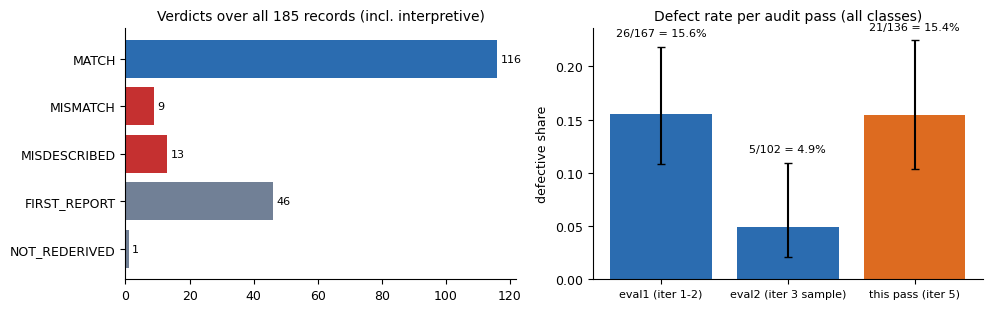

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
vc = Counter(r["verdict"] for r in recs)
order = [x for x in ("MATCH", "MISMATCH", "MISDESCRIBED", "SIGN_REVERSED", "UNTRACEABLE", "FIRST_REPORT", "NOT_REDERIVED") if vc.get(x)]
axes[0].barh(order[::-1], [vc[x] for x in order[::-1]], color=["#718096" if x in ("FIRST_REPORT", "NOT_REDERIVED") else
                                                              ("#2b6cb0" if x == "MATCH" else "#c53030") for x in order[::-1]])
for i, x in enumerate(order[::-1]):
    axes[0].text(vc[x] + 1, i, str(vc[x]), va="center", fontsize=8)
axes[0].set_title(f"Verdicts over all {len(recs)} records (incl. interpretive)", fontsize=10)
passes = [(lab, p["k_all"], p["n"]) for lab, p in PRIORS.items()] + [("this pass (iter 5)", k, n)]
for j, (lab, kk, nn) in enumerate(passes):
    lo_, hi_ = wilson(kk, nn); p_ = kk / nn
    axes[1].bar(j, p_, color="#2b6cb0" if j < 2 else "#dd6b20")
    axes[1].errorbar(j, p_, yerr=[[p_ - lo_], [hi_ - p_]], fmt="none", ecolor="black", capsize=3)
    axes[1].text(j, hi_ + 0.01, f"{kk}/{nn} = {p_:.1%}", ha="center", fontsize=8)
axes[1].set_xticks(range(len(passes))); axes[1].set_xticklabels([p[0] for p in passes], fontsize=8)
axes[1].set_ylabel("defective share"); axes[1].set_title("Defect rate per audit pass (all classes)", fontsize=10)
plt.tight_layout(); plt.show()

The three figures the original pipeline writes to `figures/`:

fig1_mismatch_rate_passes


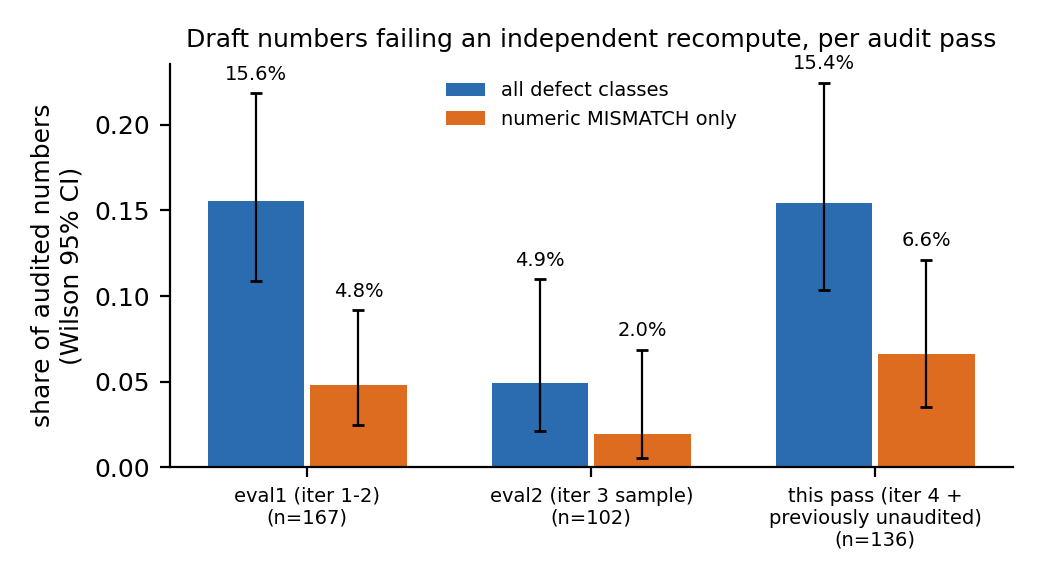

fig2_forest_recomputed_contrasts


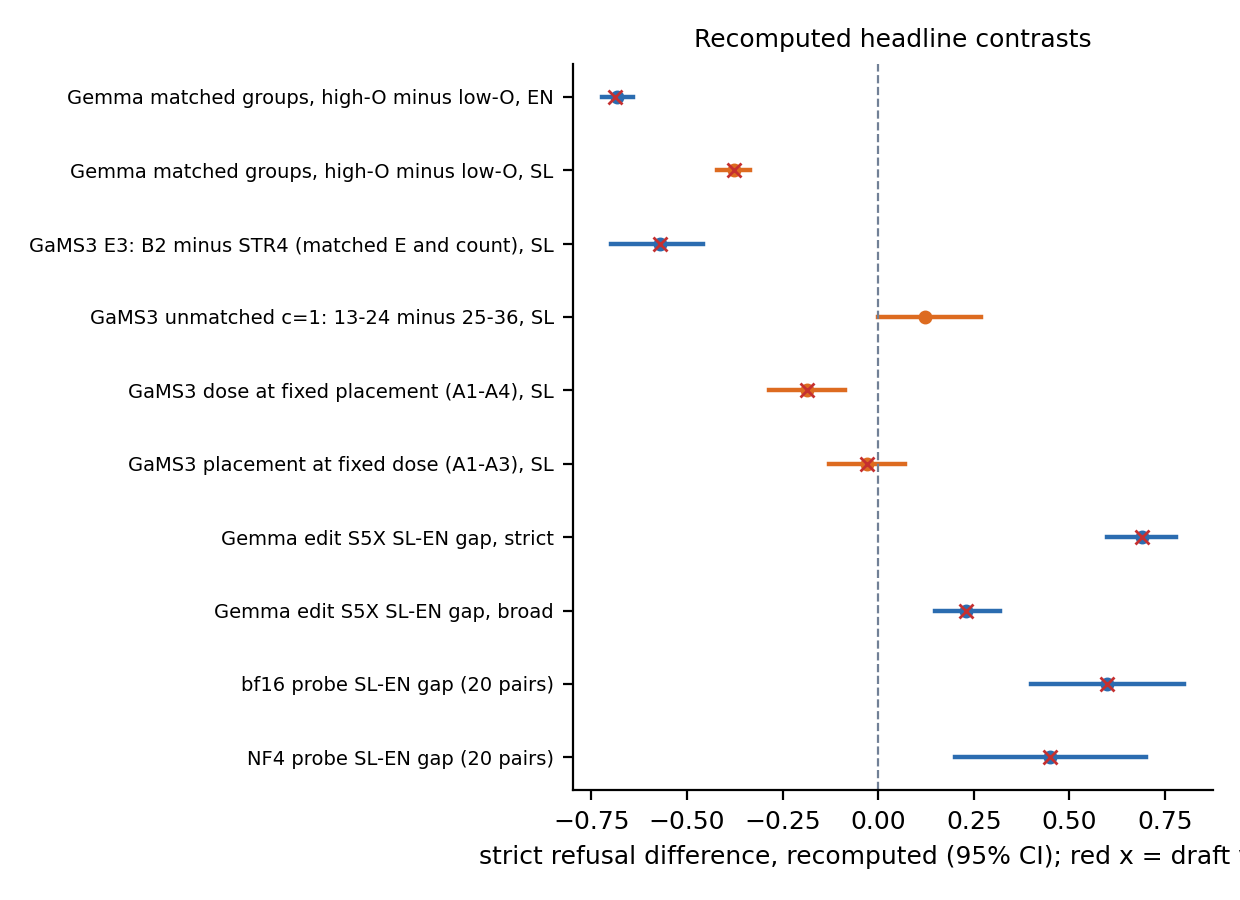

fig3_kappa_pooled_vs_edited


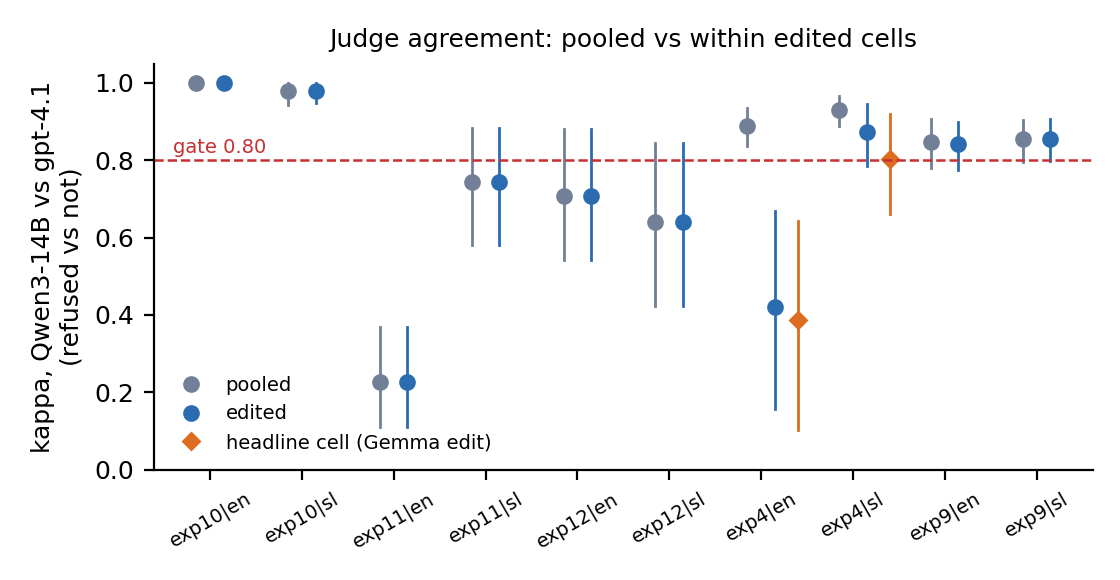

In [31]:
for name in ("fig1_mismatch_rate_passes", "fig2_forest_recomputed_contrasts", "fig3_kappa_pooled_vs_edited"):
    print(name); display(Image(filename=str(FIG / f"{name}.png"), width=620))

Finally, the opening of the paste-ready repair blocks (`results/report_repairs_iter5.md`), which fill in their numbers from the records above:

In [32]:
rep_md = (RES / "report_repairs_iter5.md").read_text()
display(Markdown(rep_md[:rep_md.index("## R2")]))
print(f"... ({len(rep_md):,} characters in total, blocks R1-R12)")

# Iteration-5 repair blocks R1-R12 (paste-ready)

Audited draft: `iter_4/gen_report_text/gen_report_text/paper_draft.md`. Every path below is relative to `3_invention_loop/`. Numbers come from this audit's
independent recompute (`rederive_iter5.py`, imports: stdlib, numpy, pyarrow) unless marked **[carried: path]**.
Verdict vocabulary: MATCH / MISMATCH / MISDESCRIBED / UNTRACEABLE / SIGN_REVERSED (the same as the iteration-3 and iteration-4 passes).

**Audit headline.** 136 first-pass numbers with a draft value were re-derived; 21 are defective
(15.4%, Wilson 95% CI [10.3%, 22.5%]), of which 14 are material (they change what a sentence claims).
Comparable priors under the SAME all-class definition: eval1 26/167 = 15.6% (quoted in the draft as '5.5%', which counts a
narrower class) and eval2 5/102 = 4.9%. This pass is weighted onto sections nobody had recomputed, and the interpretive defects concentrate there.
Counting numeric MISMATCHes only: 9/136. No number was SIGN_REVERSED.

---

## R1 - Placement restatement (replaces 'Firm positive', 'Iteration-4 additions' and 'The surviving finding')

**Observation.** At matched total removal energy AND matched layer count, where the edit energy sits orders residual refusal.
- **Gemma (exp13).** High-O beats low-O in 8/8 matched groups in EN and 8/8 in SL. Pooled contrast EN -0.682 [-0.72, -0.64], SL -0.377 [-0.42, -0.34] (paired item bootstrap; judge Qwen3-14B; SL within-edited kappa 0.729, below the 0.80 gate, so SL is JUDGE_SENSITIVE: Rogan-Gladen companion for the best SL cell: raw 0.27 -> 0.00, with Se/Sp taken from the 390-row gpt-4.1 overlap; a companion clipped at 0 means the correction is unstable at that specificity, so the SL cell rate is a range [0.00, 0.27], not a point). Source: `iter_4/gen_art/gen_art_experiment_13/results/per_item.csv`, `iter_4/gen_art/gen_art_experiment_13/results/cells/*.json`.
- **GaMS3 (exp14).** Spearman rho(O_SL, strict SL refusal) = -0.900 over 20 confirmation cells (draft -0.903 [-0.928, -0.857] **[carried: `iter_4/gen_art/gen_art_experiment_14/results/analysis_summary.json` primary.sl.ci]**), within level E2 -0.976, E3 -0.948. Source: `iter_4/gen_art/gen_art_experiment_14/results/per_item.parquet`, `iter_4/gen_art/gen_art_experiment_14/results/cells.csv`.
- **Qwen3-8B (exp13 outside panel).** 9/9 matched contrasts favour the better-placed member; Spearman rho(O) EN -0.72, SL -0.93, DE -0.94 (all valid items; the artifact's 39-item subset gives -0.76 / -0.93 / -0.84). 8/9 CIs excluding zero: **[carried: `iter_4/gen_art/gen_art_experiment_13/results/report_tables.md`]**.
- **The dose rival FAILS.** Doubling the energy in the late band (layers 33-48) leaves EN 0.88 / SL 0.92, against the mid band (16-31) at EN 0.07 / SL 0.27 at matched energy.
- **The winning band at matched energy is the SAME in both siblings.** GaMS3 SL strict: E2 B2 0.50 < B3 0.59 < B4 0.94 < B1 0.97; E3 B2 0.30 < B3 0.53 < B4 0.94 < B1 0.97. Gemma's frozen argmax prediction (13-24) PASSES; the GaMS3 DEV profile's prediction (25-36) is NAMED_AND_LOST.
- **UNRESOLVED disagreement, reported as such.** The UNMATCHED c = 1 grid in exp10 favours 25-36 over 13-24 by +0.12 [+0.00, +0.27] (SL strict, paired items; eval2's R1 correction gave +0.12 [0.02, 0.22]). The matched-energy panels and this unmatched grid differ in design (matched vs unmatched dose). This audit verifies both numbers and does not adjudicate.

**STRIKE** 'the critical band differs between siblings' everywhere it appears: as a finding (line 887), as a novelty qualifier (line 682, 'the critical band moves between sibling checkpoints'), and as the candidate explanation of the iteration-1 dissociation (line 861). Only the DEV profile's argmax differs (layer 27 vs 19); the behavioural winner does not. **No band recommendation is made.**



... (20,082 characters in total, blocks R1-R12)
